# **Introducción**
## Producción de Pozos No Convencionales – Argentina

En este proyecto se analizará un dataset de producción de pozos no convencionales de Argentina, con el objetivo de comprender la estructura de los datos, identificar las variables disponibles y evaluar su calidad.

El interés en este dataset surge de la relevancia que tiene la producción no convencional dentro de la industria energética, así como de la posibilidad de relacionar características técnicas de los pozos con su comportamiento productivo.

A partir de este análisis, se buscará aplicar técnicas de Machine Learning para intentar responder preguntas del tipo:
**“Dado un pozo nuevo, ¿cuánto petróleo podría producir por mes, en función de su formación, profundidad y sistema de extracción?”**

Este tipo de modelos resulta útil para la planificación operativa y la estimación del potencial productivo de nuevos pozos, contribuyendo a una mejor toma de decisiones técnicas.

Para lograrlo, se utilizarán como variables independientes, las siguientes:

Formación geológica

Tipo de extracción

Sub-tipo de recurso

Profundidad del pozo

Mes de producción

prod_agua y prod_gas


# **Análisis exploratorio de datos (EDA)**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import matplotlib.dates as mdates
%matplotlib inline


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta = "/content/drive/My Drive/produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv"
df = pd.read_csv(ruta, low_memory=False)
df.head()


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YSUR,2018,1,132491,5.466,131.734,3.81,0.0,0.0,0.0,...,NEUQUINA,Neuquén,-69.183251,-39.083192,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
1,YSUR,2017,1,130022,0.000,182.600,9.23,0.0,0.0,0.0,...,NEUQUINA,Neuquén,-69.720525,-39.008460,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
2,YSUR,2018,1,132489,2.201,164.605,7.03,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.865009,-39.016697,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
3,YSUR,2017,1,135208,0.000,105.300,0.00,0.0,0.0,0.0,...,NEUQUINA,Neuquén,-69.715565,-39.007522,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
4,YSUR,2018,1,132488,0.000,171.937,0.00,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.864960,-39.016722,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31


In [ ]:
df.shape


(372530, 40)

In [ ]:
df.columns


Index(['idempresa', 'anio', 'mes', 'idpozo', 'prod_pet', 'prod_gas',
       'prod_agua', 'iny_agua', 'iny_gas', 'iny_co2', 'iny_otro', 'tef',
       'vida_util', 'tipoextraccion', 'tipoestado', 'tipopozo',
       'observaciones', 'fechaingreso', 'rectificado', 'habilitado',
       'idusuario', 'empresa', 'sigla', 'formprod', 'profundidad', 'formacion',
       'idareapermisoconcesion', 'areapermisoconcesion', 'idareayacimiento',
       'areayacimiento', 'cuenca', 'provincia', 'coordenadax', 'coordenaday',
       'tipo_de_recurso', 'proyecto', 'clasificacion', 'subclasificacion',
       'sub_tipo_recurso', 'fecha_data'],
      dtype='object')

In [ ]:
df = df.rename(columns={'sigla': 'nombrepozo'})


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372530 entries, 0 to 372529
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               372530 non-null  object 
 1   anio                    372530 non-null  int64  
 2   mes                     372530 non-null  int64  
 3   idpozo                  372530 non-null  int64  
 4   prod_pet                372530 non-null  float64
 5   prod_gas                372530 non-null  float64
 6   prod_agua               372530 non-null  float64
 7   iny_agua                372530 non-null  float64
 8   iny_gas                 372530 non-null  float64
 9   iny_co2                 372530 non-null  float64
 10  iny_otro                372530 non-null  float64
 11  tef                     372530 non-null  float64
 12  vida_util               7807 non-null    float64
 13  tipoextraccion          371937 non-null  object 
 14  tipoestado          

Nota: Aca tambien podemos identificar variables categóricas, en type "object" (formación, tipo de extracción, tipo de pozo, cuenca, etc.) que serán consideradas para un posterior proceso de codificación antes del entrenamiento de modelos de Machine Learning.

Porcentaje en columnas numericas con valor igual a 0 :

In [ ]:
(df.select_dtypes(include='number') == 0).mean() * 100


,0
anio,0.000000
mes,0.000000
idpozo,0.000000
prod_pet,35.917107
prod_gas,20.625721
prod_agua,30.415269
iny_agua,99.877325
iny_gas,99.897995
iny_co2,100.000000
iny_otro,100.000000


## Decisiones de limpieza inicial
A partir de la inspección de la estructura del dataset, se observa que algunas columnas presentan una alta cantidad de valores nulos (NaN), otras con valores igual a 0 y otras que contienen información repetitiva que no resulta relevante para el análisis productivo.

En particular, las columnas vida_util y observaciones presentan más del 80–90% de valores faltantes (NaN), por lo que se decide excluirlas del análisis.

Las columnas de inyección tienen casi todos sus valores son iguales a 0, por lo cual seran eliminadas.

Asimismo, se eliminan las columnas : rectificado, habilitado, formprod, areapermisoconcesion, idareapermisoconcesion, provincia y proyecto. Debido a que algunas no son relevantes y otras repien información existente en otras columnas del dataset.

In [ ]:

df["tipoestado"].value_counts()


,count
tipoestado,
Extracción Efectiva,308124
Parado Transitoriamente,23001
En Estudio,21704
Abandonado,3099
Otras Situación Inactivo,3074
A Abandonar,2937
En Reserva de Gas,2716
En Espera de Reparación,2333
Otras Situación Activo,2138


In [ ]:
columnas_a_eliminar = [
    'vida_util',
    'observaciones',
    'rectificado',
    'habilitado',
    'formprod',
    'areapermisoconcesion',
    'provincia',
    'proyecto',
    'idareapermisoconcesion',
    'iny_agua',
    'iny_gas',
    'iny_co2',
    'iny_otro',
    'idusuario'
]

df = df.drop(columns=columnas_a_eliminar)


In [ ]:
df.columns

Index(['idempresa', 'anio', 'mes', 'idpozo', 'prod_pet', 'prod_gas',
       'prod_agua', 'tef', 'tipoextraccion', 'tipoestado', 'tipopozo',
       'fechaingreso', 'empresa', 'nombrepozo', 'profundidad', 'formacion',
       'idareayacimiento', 'areayacimiento', 'cuenca', 'coordenadax',
       'coordenaday', 'tipo_de_recurso', 'clasificacion', 'subclasificacion',
       'sub_tipo_recurso', 'fecha_data'],
      dtype='object')

Rellenamos clasificaciones faltantes

In [ ]:
cols_fill = ['clasificacion','subclasificacion','tipopozo','tipoestado','tipoextraccion','sub_tipo_recurso']
for c in cols_fill:
    df[c] = df[c].fillna('DESCONOCIDO')


Corroboramos nuevamente datos nulos o faltantes.

In [ ]:
df.isnull().sum().sort_values(ascending=False)


,0
idempresa,0
anio,0
mes,0
idpozo,0
prod_pet,0
prod_gas,0
prod_agua,0
tef,0
tipoextraccion,0
tipoestado,0


Ahora fecha_data y fechaingreso estan en formato object y debemos convertirla en formato datatime.

In [ ]:
df['fecha_data'] = pd.to_datetime(df['fecha_data'], errors='coerce')
df['fechaingreso'] = pd.to_datetime(df['fechaingreso'], errors='coerce')

In [ ]:
df[['fecha_data', 'fechaingreso']].dtypes


,0
fecha_data,datetime64[ns]
fechaingreso,datetime64[ns]


Ahora analizamos si hay filas duplicadas o pozos repetidos en una misma fecha.

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.duplicated(subset=['idpozo', 'fecha_data']).sum()


np.int64(0)

Evaluamos si hay valores de producción e inyección, negativos, anómalos.

---



In [ ]:
(df[['prod_pet','prod_gas','prod_agua']] < 0).sum()


,0
prod_pet,1
prod_gas,2
prod_agua,0


In [ ]:
df[df['prod_pet'] < 0]


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,tef,tipoextraccion,tipoestado,...,idareayacimiento,areayacimiento,cuenca,coordenadax,coordenaday,tipo_de_recurso,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
287379,PBE,2008,12,73804,-0.001,0.0,0.0,0.0,Sin Sistema de Extracción,En Estudio,...,ECE,EL CERRITO,AUSTRAL,-71.139333,-50.652806,NO CONVENCIONAL,EXPLORACION,EXPLORACION,TIGHT,2008-12-31


No representativo, se reemplaza por cero.



In [ ]:
df.loc[df['prod_pet'] < 0, 'prod_pet'] = 0


In [ ]:
df[df['prod_gas'] < 0]


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,tef,tipoextraccion,tipoestado,...,idareayacimiento,areayacimiento,cuenca,coordenadax,coordenaday,tipo_de_recurso,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
266201,PLU,2020,5,153227,1.02,-7.519,0.0,6.13,Surgencia Natural,Extracción Efectiva,...,CEN,CENTENARIO CENTRO,NEUQUINA,-68.179297,-38.920979,NO CONVENCIONAL,EXPLOTACION,DESARROLLO,TIGHT,2020-05-31
266210,PLU,2020,5,153228,1.67,-12.267,0.0,6.13,Surgencia Natural,Extracción Efectiva,...,CEN,CENTENARIO CENTRO,NEUQUINA,-68.179297,-38.920979,NO CONVENCIONAL,EXPLOTACION,DESARROLLO,TIGHT,2020-05-31


No son representativos, se reemplazan por cero

In [ ]:
df.loc[df['prod_gas'] < 0, 'prod_gas'] = 0


Cantidad de pozos en estudio:

In [ ]:
df['idpozo'].nunique()


4651

Formaciones disponibles:

In [ ]:
df['formacion'].unique()


array(['precuyo', 'lajas', 'formación improductiva', 'quintuco',
       'basamento', 'vaca muerta', 'lotena', 'los molles', 'mulichinco',
       'punta rosada', 'sierras blancas', 'agrio', 'pozo d-129',
       'centenario', 'grupo neuquén', 'rayoso', 'grupo chubut', 'chachao',
       'tordillo', 'mina el carmen', 'yacoraite', 'loma montosa',
       'magallanes', 'springhill', 'palermo aike', 'ANITA', 'tobífera',
       'bajo barreal', 'cañadon seco'], dtype=object)

Tipos de extracción:

In [ ]:
df['tipoextraccion'].unique()


array(['Plunger Lift', 'Surgencia Natural', 'Bombeo Mecánico',
       'Sin Sistema de Extracción', 'Otros Tipos de Extracción',
       'Gas Lift', 'Bombeo Hidráulico', 'Electrosumergible', 'Jet Pump',
       'DESCONOCIDO', 'Pistoneo (Swabbing)', 'Cavidad Progresiva'],
      dtype=object)

## Diccionario de variables

**Identificadores / administrativos**
- **idpozo**: identificador del pozo.
- **idempresa**: identificador de la empresa/operador.
- **empresa**: nombre de la empresa/operador.
- **nombrepozo**: Nombre completo del pozo.

**Tiempo**
- **anio**: año del registro.
- **mes**: mes del registro.
- **fecha_data**: fecha del registro mensual de producción.
- **fechaingreso**: fecha de ingreso/carga del registro.

**Producción mensual**
- **prod_pet**: producción mensual de petróleo (m³).
- **prod_gas**: producción mensual de gas (m³ estandar).
- **prod_agua**: producción mensual de agua (m³).

**Variables técnicas**
- **tipoextraccion**: sistema de extracción utilizado.
- **tipopozo**: tipo de pozo (Petrolífero/Gasífero u otra clasificación).
- **profundidad**: profundidad del pozo (m).
- **tef**: variable técnica del dataset (se mantiene para revisar su utilidad en etapas posteriores).

**Geología / ubicación**
- **formacion**: formación geológica.
- **cuenca**: cuenca hidrocarburífera.
- **idareayacimiento**: identificador del área/yacimiento.
- **areayacimiento**: nombre del área/yacimiento.
- **coordenadax**: coordenada X del pozo.
- **coordenaday**: coordenada Y del pozo.

**Clasificación del recurso**
- **tipo_de_recurso**: Convencional/No Convencional.
- **clasificacion**: clasificación general.
- **subclasificacion**: En explotación o servicio.
- **sub_tipo_recurso**: Clasificación geológica (por ejemplo tight/shale, etc.).
- **tipoestado**: Define si esta parado transitoriamente o con extracción efectiva.


##Análisis Estadistico

In [ ]:
# Estadística producciones
df[['prod_pet','prod_gas','prod_agua']].describe()


,prod_pet,prod_gas,prod_agua
count,372530.000000,372530.000000,372530.000000
mean,298.235059,635.224085,170.662041
std,873.008508,1619.018027,571.377186
min,0.000000,0.000000,0.000000
25%,0.000000,8.270000,0.000000
50%,7.070000,107.368789,12.130000
75%,97.146248,465.358500,79.610000
max,26593.261000,29129.660000,34792.950000


El análisis estadístico preliminar del dataset muestra que la producción mensual de los pozos presenta una altísima dispersión y una distribución altamente asimétrica. La gran mayoría de los pozos registra volúmenes muy bajos (el 50% produce menos de 7 m³/mes de petróleo y el 75% produce menos de 100 m³/mes), mientras que un grupo reducido concentra las producciones más altas, alcanzando valores superiores a 25.000–30.000 m³/mes. Esto indica que el promedio no es representativo del comportamiento general, ya que está fuertemente influenciado por unos pocos pozos de gran rendimiento; en cambio, la mediana refleja mucho mejor el nivel típico de producción del conjunto.

En resumen, se trata de un dataset caracterizado por una población heterogénea de pozos, dominada por unidades marginales o de baja productividad y complementada por un pequeño número de pozos altamente productivos que generan la mayor parte del volumen total.

In [ ]:
df[df['prod_pet'] == df['prod_pet'].max()]


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,tef,tipoextraccion,tipoestado,...,idareayacimiento,areayacimiento,cuenca,coordenadax,coordenaday,tipo_de_recurso,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
214205,VST,2025,1,164941,26593.261,1785.859,8816.35,30.951,Surgencia Natural,Extracción Efectiva,...,BPO,BAJADA DEL PALO OESTE,NEUQUINA,-68.520315,-38.156831,NO CONVENCIONAL,EXPLOTACION,DESARROLLO,SHALE,2025-01-31


In [ ]:
df[df['prod_gas'] == df['prod_gas'].max()]

,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,tef,tipoextraccion,tipoestado,...,idareayacimiento,areayacimiento,cuenca,coordenadax,coordenaday,tipo_de_recurso,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
233917,TPT,2021,12,162597,884.8927,29129.66,4980.403,31.0,Surgencia Natural,Extracción Efectiva,...,FOR,FORTIN DE PIEDRA,NEUQUINA,-69.145471,-38.541492,NO CONVENCIONAL,EXPLOTACION,DESARROLLO,SHALE,2021-12-31


### Paquete de graficos

###Histograma log

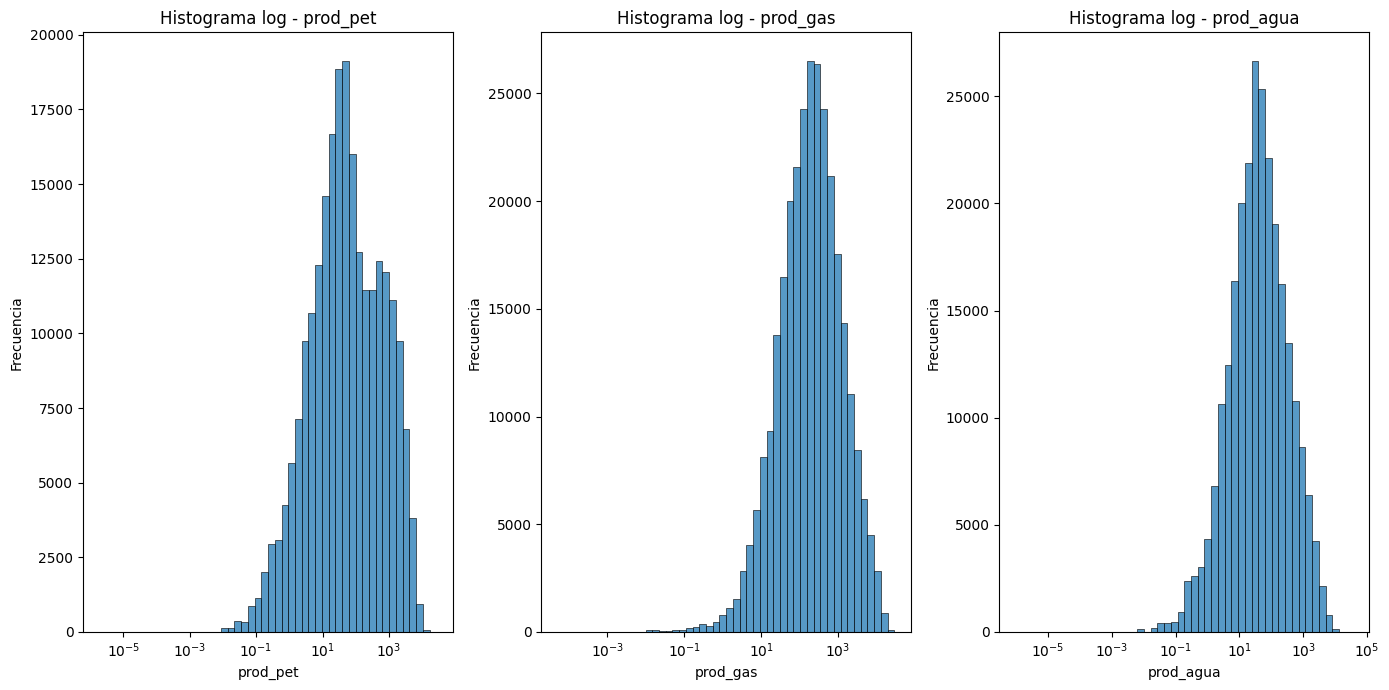

In [ ]:
cols = ['prod_pet', 'prod_gas', 'prod_agua']

plt.figure(figsize=(14,7))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=50, log_scale=True)
    plt.title(f"Histograma log - {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

###Boxplot log

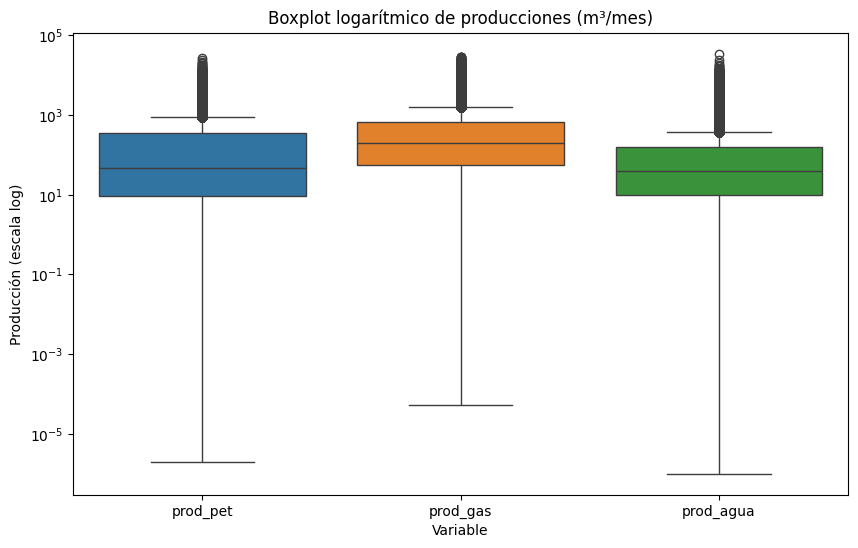

In [ ]:
# Creamos una copia en log10 para evitar problemas con ceros
df_box = df[['prod_pet', 'prod_gas', 'prod_agua']].copy()

# Para evitar log(0), reemplazamos 0 por un valor muy chico
for col in df_box.columns:
    df_box[col] = df_box[col].replace(0, np.nan)   # NaN no se dibuja en el boxplot

plt.figure(figsize=(10,6))
sns.boxplot(data=df_box)
plt.yscale('log')
plt.title("Boxplot logarítmico de producciones (m³/mes)")
plt.ylabel("Producción (escala log)")
plt.xlabel("Variable")
plt.show()

###Grafico Pareto_Ranking de pozos por produccion total

🏁 Se necesitan 1256 pozos para llegar al 80% del total de petróleo.


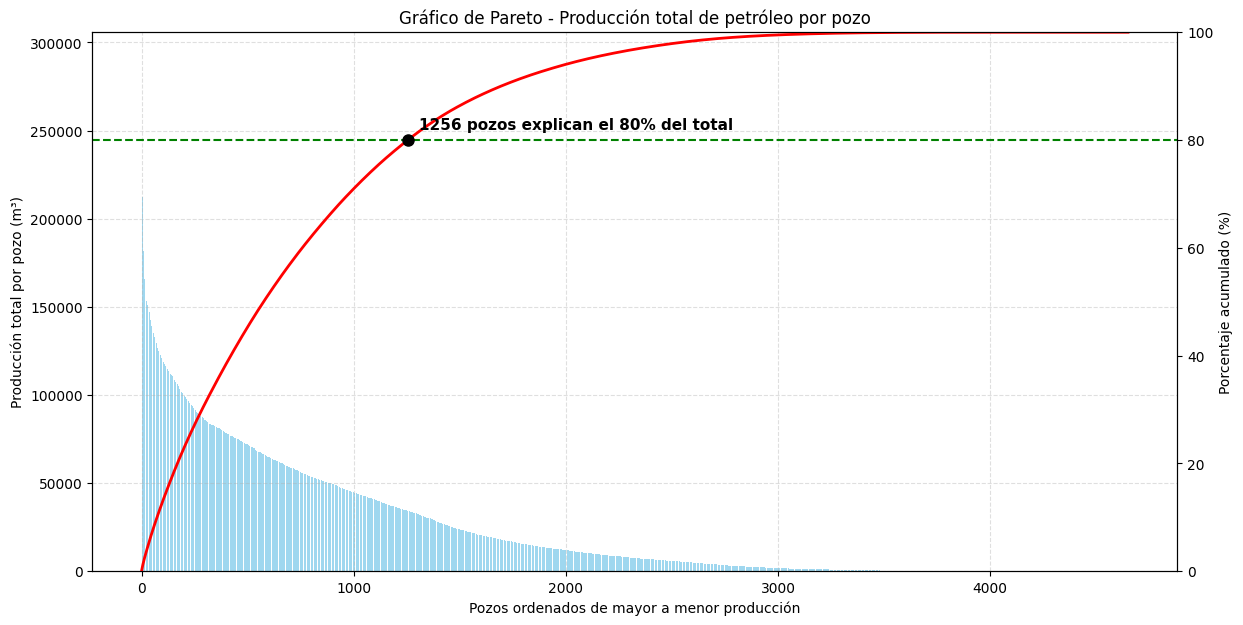

In [ ]:

prod_total_pozo = df.groupby('idpozo')['prod_pet'].sum().sort_values(ascending=False)

values = prod_total_pozo.values  # producciones totales ordenadas


cum_percentage = (np.cumsum(values) / values.sum()) * 100

# Lo convierto en Series para poder usar idxmax()
cum_percentage = pd.Series(cum_percentage)

# es para encontrar el 80%, dejarlo ubicado
target = 80
idx_80 = (cum_percentage >= target).idxmax()
pozos_para_80 = idx_80 + 1  # número de pozos necesarios para llegar al 80%

print(f"🏁 Se necesitan {pozos_para_80} pozos para llegar al 80% del total de petróleo.")

# 4) GRAFICAR EL PARETO

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- BARRAS (Producción total por pozo)
ax1.bar(range(len(values)), values, color='skyblue', alpha=0.8)
ax1.set_ylabel("Producción total por pozo (m³)")
ax1.set_xlabel("Pozos ordenados de mayor a menor producción")
ax1.set_title("Gráfico de Pareto - Producción total de petróleo por pozo")

# --- EJE SECUNDARIO (Porcentaje acumulado) ---
ax2 = ax1.twinx()
ax2.plot(range(len(values)), cum_percentage, color='red', linewidth=2)
ax2.set_ylabel("Porcentaje acumulado (%)")
ax2.set_ylim(0, 100)

# --- LÍNEA HORIZONTAL 80% ---
ax2.axhline(target, color='green', linestyle='--', linewidth=1.5)

# --- MARCADOR en el punto donde se alcanza el 80% ---
ax2.plot(idx_80, cum_percentage[idx_80], 'o', color='black', markersize=8)

# --- TEXTO EXPLICATIVO ---
ax2.text(idx_80 + 50, target + 2,
         f"{pozos_para_80} pozos explican el 80% del total",
         fontsize=11, color='black', fontweight='bold')

# --- FORMATO ---
ax1.grid(True, linestyle='--', alpha=0.4)
plt.show()

🔥 Se necesitan 1143 pozos para explicar el 80% del GAS total.


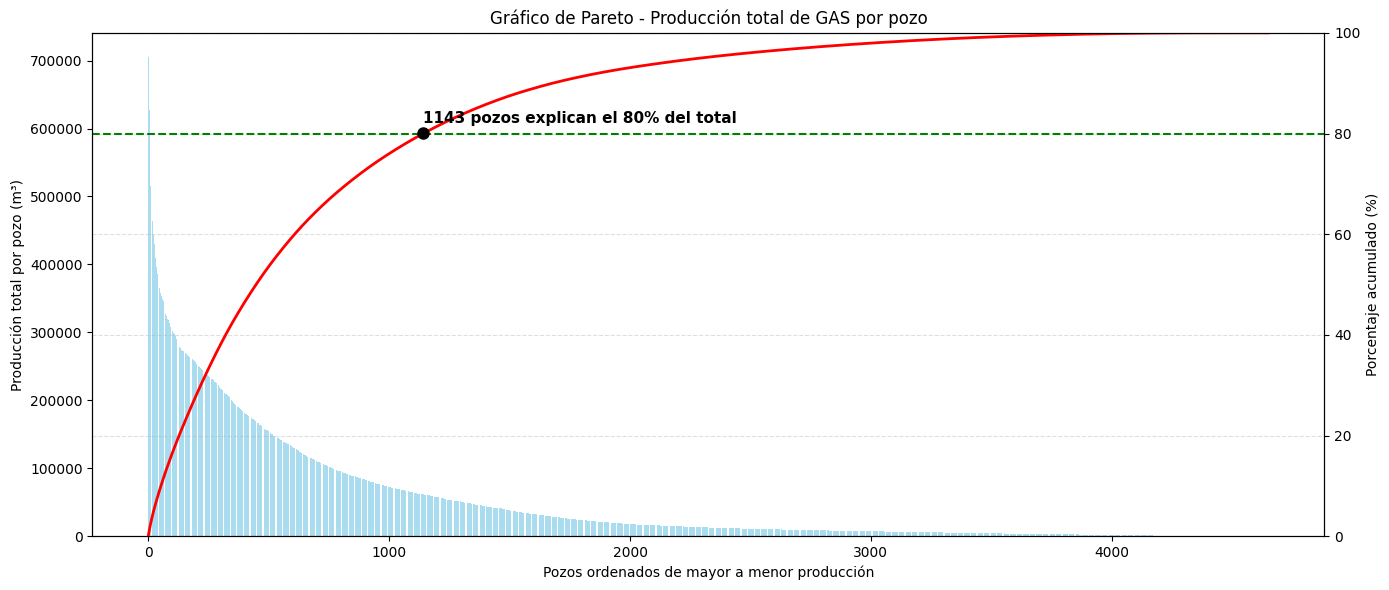

In [ ]:
# Agrupamos producción histórica total por pozo
prod_total_gas = df.groupby('idpozo')['prod_gas'].sum().sort_values(ascending=False)

values = prod_total_gas.values
cum_values = values.cumsum()
cum_percentage = 100 * cum_values / cum_values[-1]

target = 80  # 80%

import numpy as np
idx_80 = np.where(cum_percentage >= target)[0][0]
pozos_para_80 = idx_80 + 1

print(f"🔥 Se necesitan {pozos_para_80} pozos para explicar el 80% del GAS total.")

plt.figure(figsize=(14,6))

# ---- EJE PRINCIPAL (barras) ----
ax1 = plt.gca()
ax1.bar(range(len(values)), values, color='skyblue', alpha=0.7)
ax1.set_ylabel("Producción total por pozo (m³)")
ax1.set_xlabel("Pozos ordenados de mayor a menor producción")
ax1.set_title("Gráfico de Pareto - Producción total de GAS por pozo")

# ---- Curva acumulada ----
ax2 = ax1.twinx()
ax2.plot(range(len(values)), cum_percentage, color='red', linewidth=2)
ax2.set_ylabel("Porcentaje acumulado (%)")
ax2.set_ylim(0, 100)

# Línea del 80%
ax2.axhline(target, color='green', linestyle='--', linewidth=1.5)

# Punto donde se alcanza el 80%
ax2.plot(idx_80, cum_percentage[idx_80], 'o', color='black', markersize=8)

# Texto informativo
ax2.text(idx_80, target + 2,
         f"{pozos_para_80} pozos explican el 80% del total",
         fontsize=11, color='black', fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

###Producción total de petróleo por tipo de recurso (Shale / Tight / Convencional)

/tmp/ipython-input-3406690361.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prod_tipo.index, y=prod_tipo.values, palette="viridis")


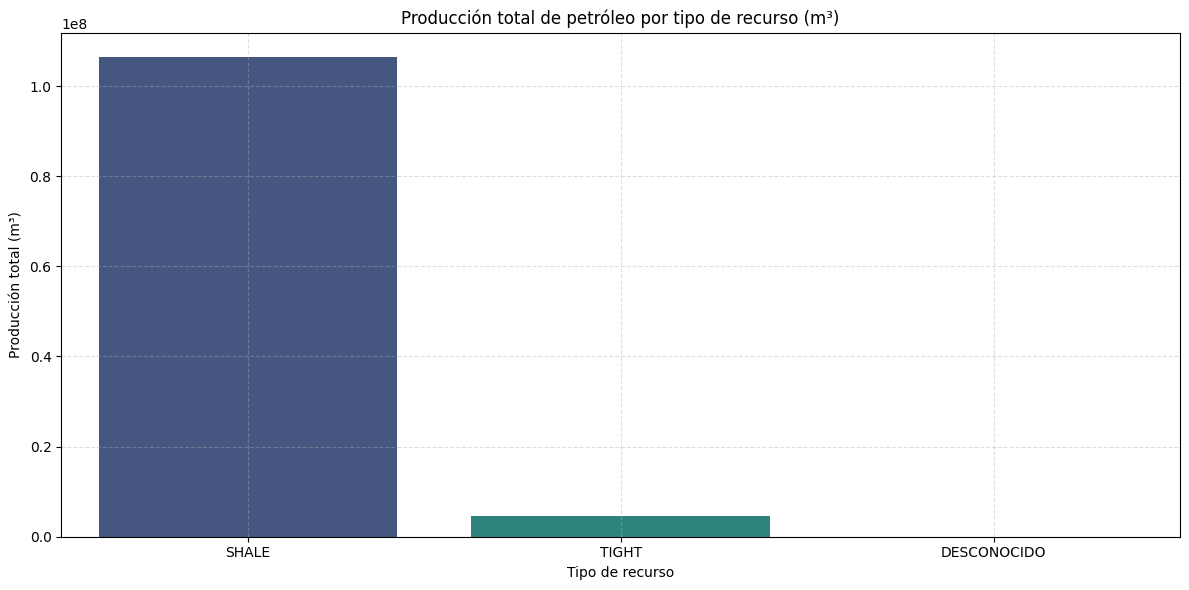

,prod_pet
sub_tipo_recurso,
SHALE,1.064843e+08
TIGHT,4.595729e+06
DESCONOCIDO,2.144504e+04


In [ ]:
# Agrupar producción por tipo de recurso
prod_tipo = df.groupby('sub_tipo_recurso')['prod_pet'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=prod_tipo.index, y=prod_tipo.values, palette="viridis")

plt.title("Producción total de petróleo por tipo de recurso (m³)")
plt.ylabel("Producción total (m³)")
plt.xlabel("Tipo de recurso")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Mostrar números exactos
prod_tipo


###Producción por empresa

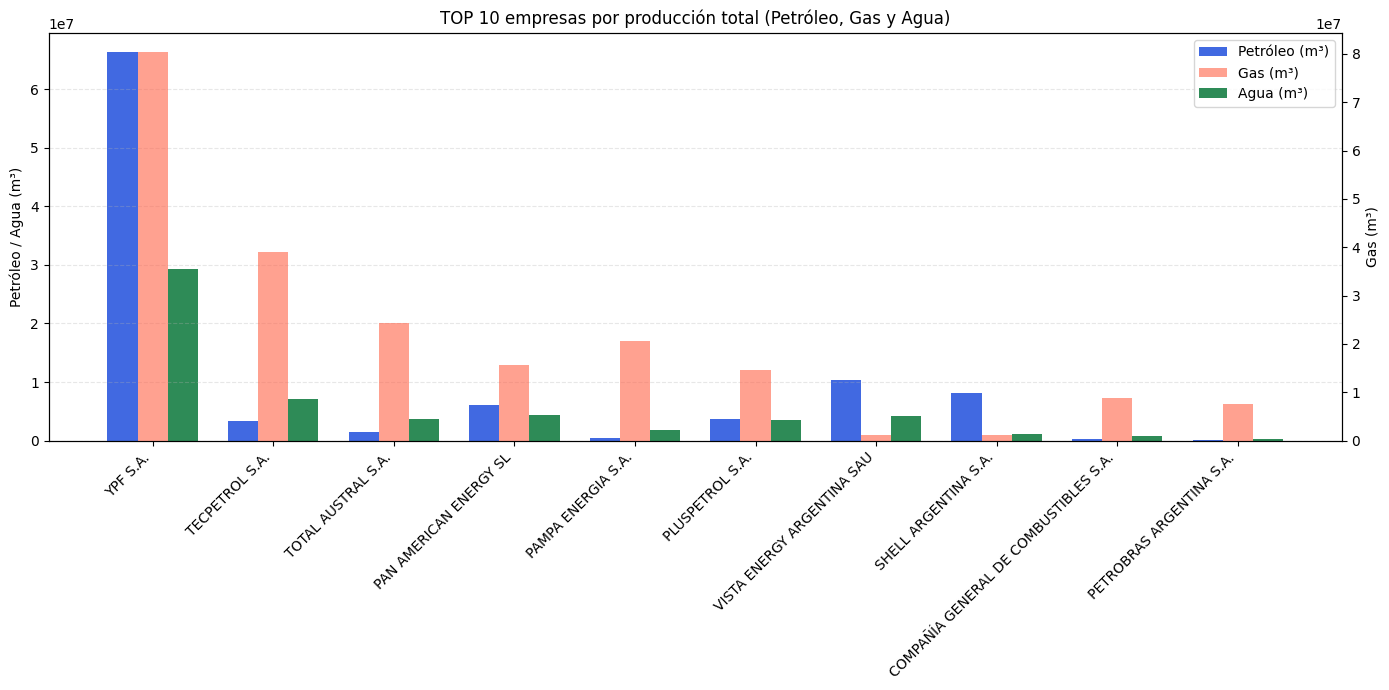

In [ ]:
# Agrupamos por empresa y sumamos producciones
prod_empresas = df.groupby('empresa')[['prod_pet', 'prod_gas', 'prod_agua']].sum()

# Ordenamos por producción total (oil+gas+agua) y tomamos top 10
prod_empresas['total'] = prod_empresas.sum(axis=1)
top10 = prod_empresas.sort_values('total', ascending=False).head(10)

empresas = top10.index
x = np.arange(len(empresas))
width = 0.25

fig, ax1 = plt.subplots(figsize=(14,7))

# --- EJE IZQUIERDO: PETRÓLEO + AGUA ---
b1 = ax1.bar(x - width, top10['prod_pet'], width, color='royalblue')
b3 = ax1.bar(x + width, top10['prod_agua'], width, color='seagreen')

ax1.set_ylabel('Petróleo / Agua (m³)')
ax1.set_xticks(x)
ax1.set_xticklabels(empresas, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- EJE DERECHO: GAS ---
ax2 = ax1.twinx()
b2 = ax2.bar(x, top10['prod_gas'], width, color='tomato', alpha=0.6)
ax2.set_ylabel('Gas (m³)')

# --- TÍTULO ---
plt.title('TOP 10 empresas por producción total (Petróleo, Gas y Agua)')

# --- LEYENDA ---
b1.set_label('Petróleo (m³)')
b2.set_label('Gas (m³)')
b3.set_label('Agua (m³)')
ax1.legend(handles=[b1, b2, b3], loc='upper right')

plt.tight_layout()
plt.show()

###Matriz de correlación

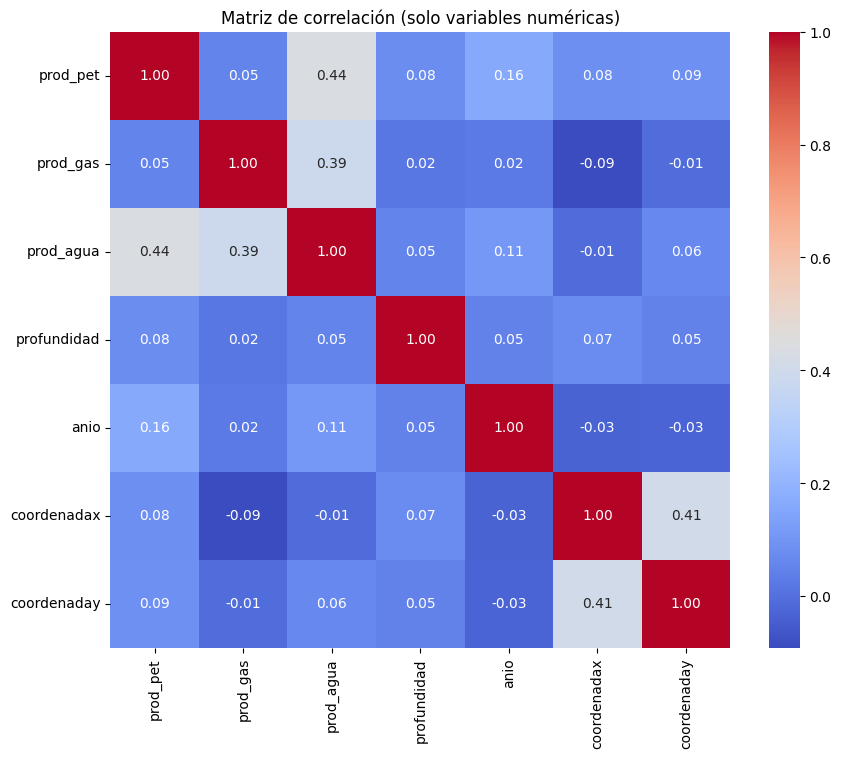

In [ ]:
df_numerico = df[['prod_pet','prod_gas','prod_agua','profundidad','anio','coordenadax','coordenaday']]

plt.figure(figsize=(10,8))
sns.heatmap(df_numerico.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación (solo variables numéricas)")
plt.show()


La matriz de correlación numérica evidencia correlaciones moderadas entre las variables de producción, particularmente entre petróleo y agua, lo cual es consistente con el comportamiento productivo de los pozos. Al incorporar la profundidad, se observa una asociación lineal moderada entre esta variable y la producción de petróleo, y en menor medida con la producción de agua y gas, lo que sugiere que la profundidad constituye un factor relevante, aunque no determinante, en el desempeño productivo. Asimismo, no se identifican relaciones lineales significativas entre las producciones y las coordenadas geográficas, ni una tendencia temporal fuerte a nivel mensual. En conjunto, los resultados indican una baja multicolinealidad entre las variables numéricas analizadas y justifican su uso conjunto en etapas posteriores de modelado.

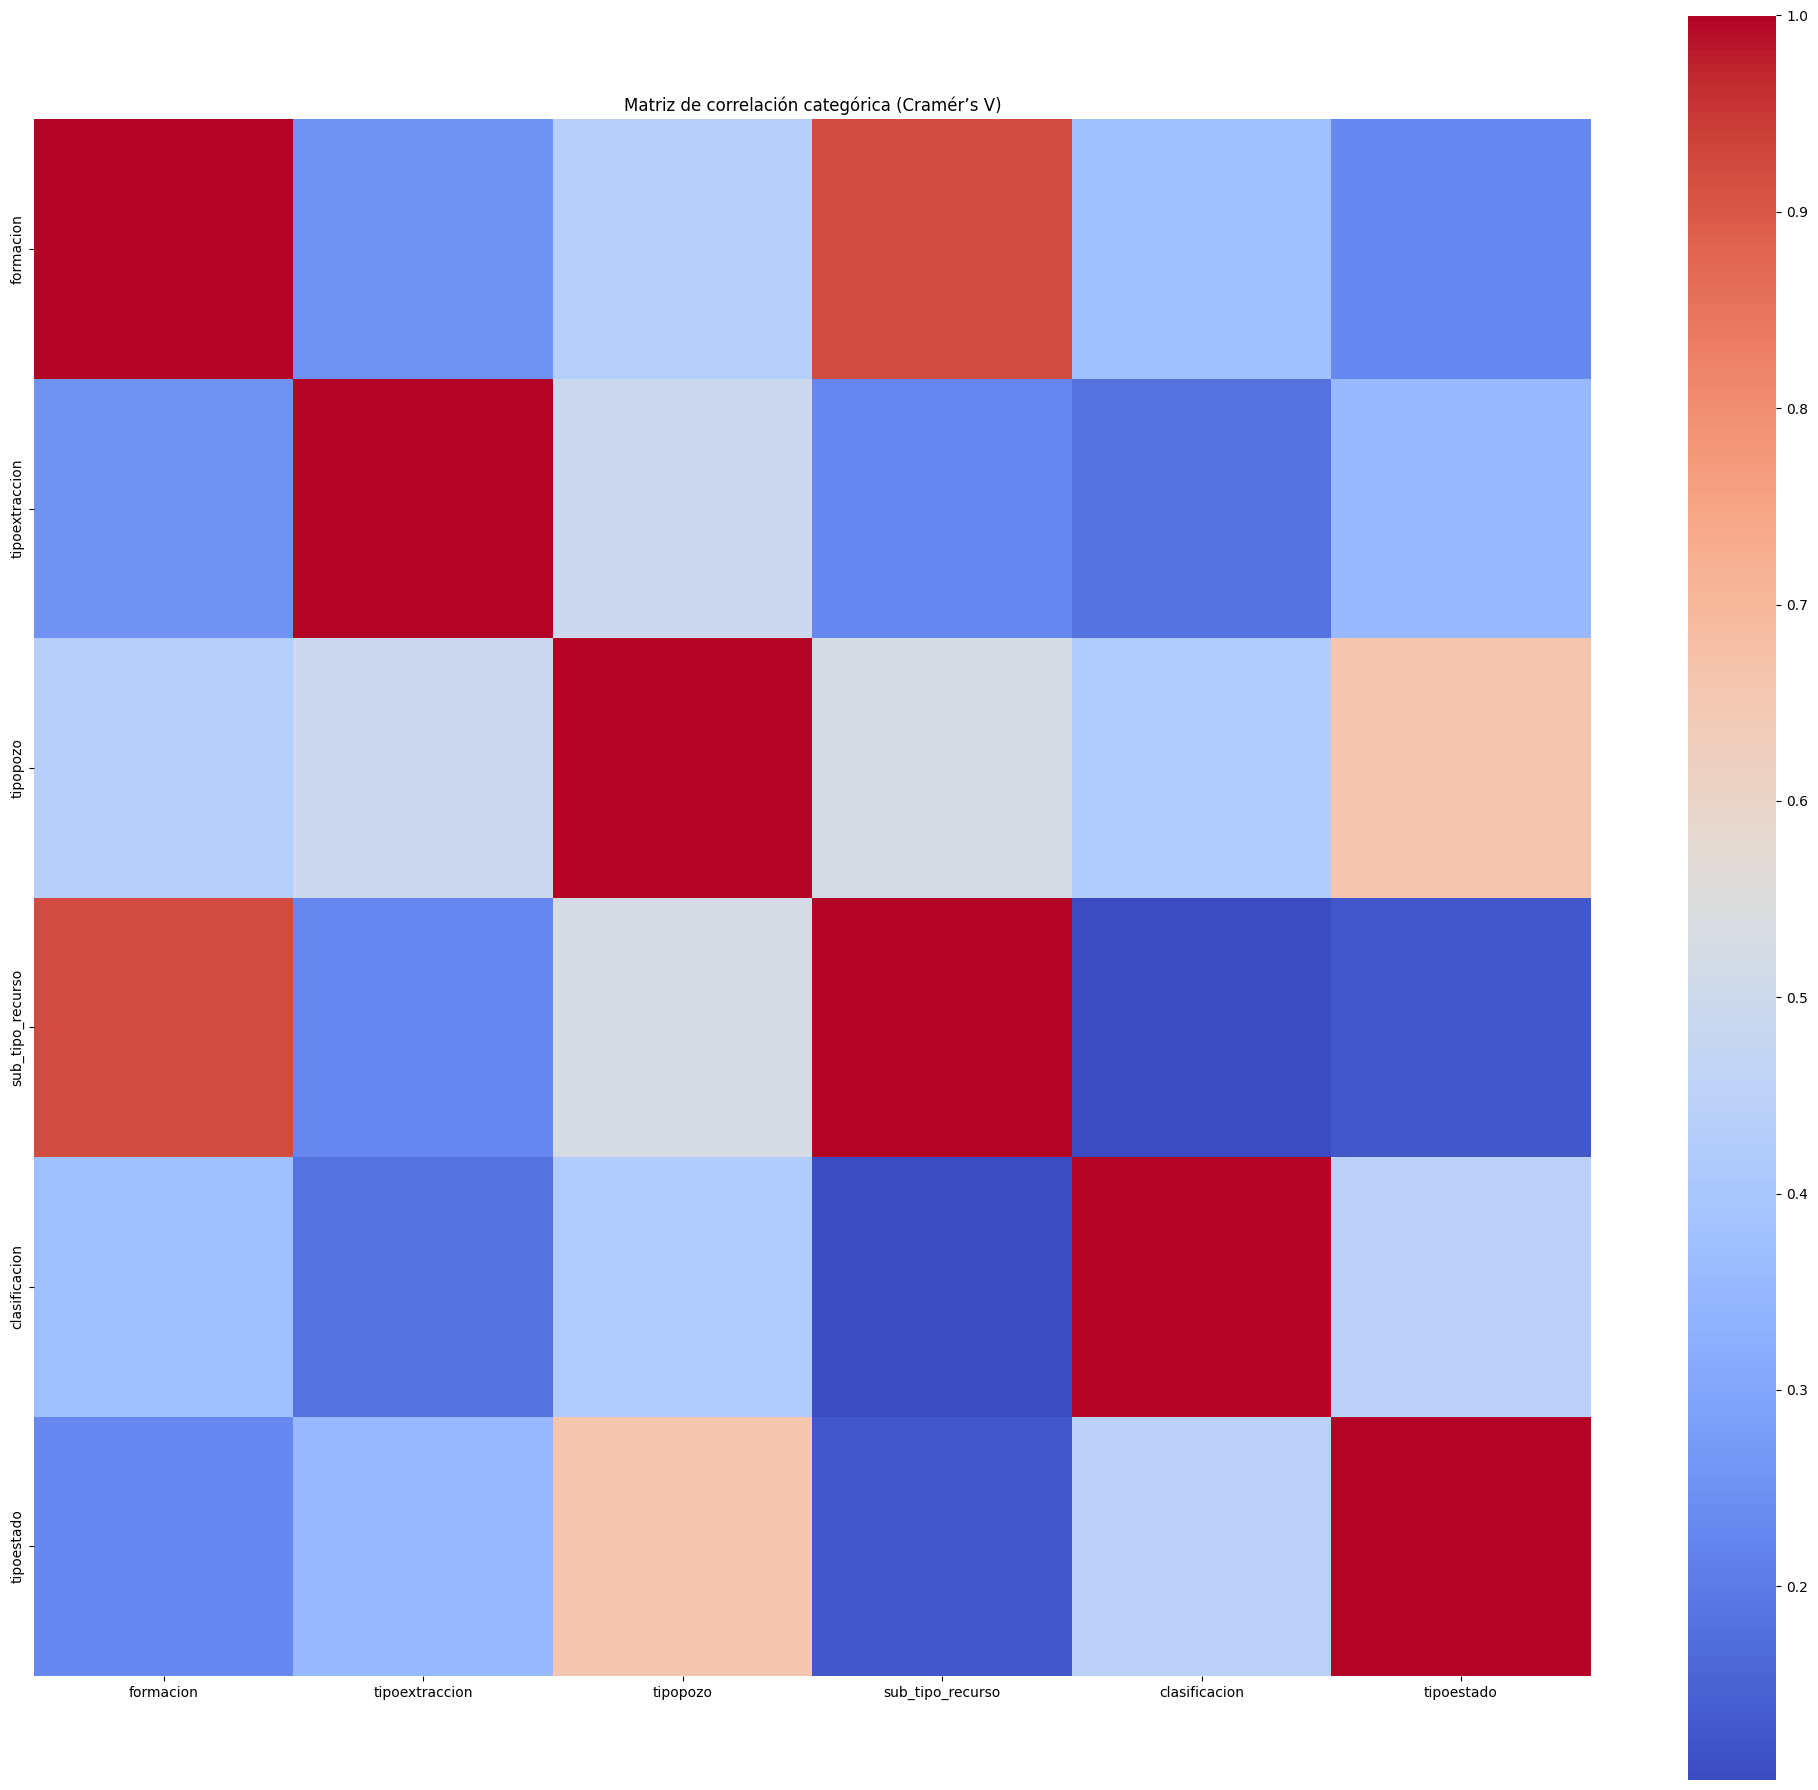

In [ ]:
# --- FUNCIÓN PARA CALCULAR CRAMÉR'S V ---
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# --- SELECCIONAMOS SOLO COLUMNAS CATEGÓRICAS ---
categoricas= [
    'formacion',
    'tipoextraccion',
    'tipopozo',
    'sub_tipo_recurso',
    'clasificacion',
    'tipoestado'
]


# Creamos matriz vacía
matriz = pd.DataFrame(np.zeros((len(categoricas), len(categoricas))),
                      index=categoricas, columns=categoricas)

# Llenamos la matriz con Cramér's V
for col1 in categoricas:
    for col2 in categoricas:
        try:
            matriz.loc[col1, col2] = cramers_v(df[col1], df[col2])
        except:
            matriz.loc[col1, col2] = np.nan

# --- GRAFICO HEATMAP ---
plt.figure(figsize=(20, 18))
sns.heatmap(matriz, cmap="coolwarm", annot=False, square=True)
plt.title("Matriz de correlación categórica (Cramér’s V)")
plt.tight_layout()
plt.show()

La matriz de correlación categórica muestra, en general, dependencias bajas a moderadas entre las variables analizadas, lo que indica que la mayoría de las categorías aportan información complementaria y no redundante. La única asociación fuerte se observa entre la formación geológica y el sub tipo de recurso, lo cual resulta esperable desde el punto de vista geológico. En conjunto, estos resultados sugieren que las variables categóricas seleccionadas pueden ser utilizadas simultáneamente en etapas posteriores de modelado sin incurrir en multicolinealidad categórica significativa.

###Matriz mixta (categorica y numerica)_Correlation Ratio

Función para calcular η (Correlation Ratio)

In [ ]:
import numpy as np

def correlation_ratio(categories, measurements):
    cats = np.unique(categories)
    n_total = len(measurements)

    # Media total
    mean_total = np.nanmean(measurements)

    # Suma ponderada de varianzas entre grupos
    ss_between = 0
    for cat in cats:
        group = measurements[categories == cat]
        ss_between += len(group) * (np.nanmean(group) - mean_total) ** 2

    # Varianza total
    ss_total = np.nansum((measurements - mean_total) ** 2)

    return np.sqrt(ss_between / ss_total) if ss_total > 0 else 0


Crear matriz mixta (numéricas vs categóricas)

In [ ]:
numericas = ["profundidad", "prod_pet", "prod_gas", "prod_agua","anio"]
categoricas = ["formacion", "tipoextraccion","tipopozo","sub_tipo_recurso","clasificacion","tipoestado"]


Calcular matriz eta

In [ ]:
matriz_eta = pd.DataFrame(
    index=categoricas,
    columns=numericas
)

for cat in categoricas:
    for num in numericas:
        matriz_eta.loc[cat, num] = correlation_ratio(df[cat].values, df[num].values)

matriz_eta = matriz_eta.astype(float)

Dibujar la matriz mixta

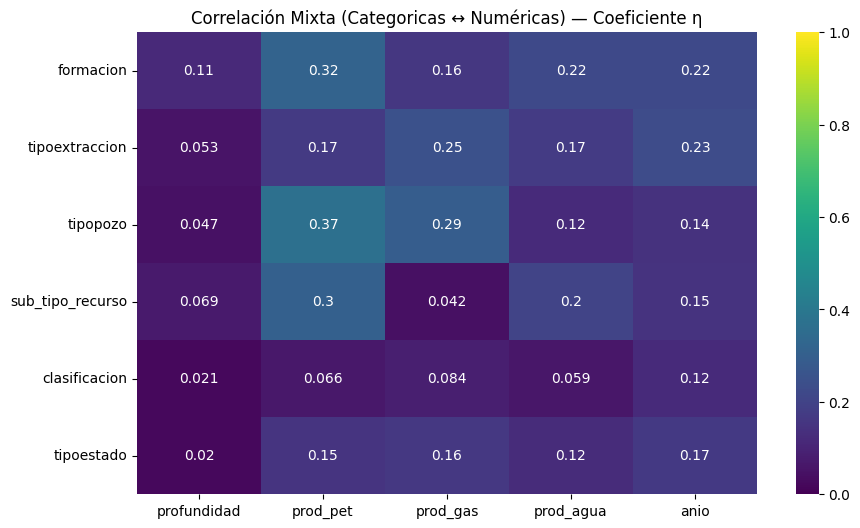

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(matriz_eta, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Correlación Mixta (Categoricas ↔ Numéricas) — Coeficiente η")
plt.show()


La matriz de correlación mixta, calculada mediante el coeficiente η (Correlation Ratio), permite evaluar la capacidad explicativa de las variables categóricas sobre las variables numéricas del dataset.

En primer lugar, la formación geológica presenta el mayor poder explicativo sobre la profundidad del pozo, con un valor de η ≈ 0.60, lo que indica que las distintas formaciones se perforan a profundidades características claramente diferenciadas. Asimismo, la formación muestra una asociación moderada con la producción de petróleo (η ≈ 0.31) y una asociación más débil con la producción de gas (η ≈ 0.16) y de agua (η ≈ 0.22), lo cual sugiere que el comportamiento productivo depende en parte de la formación, aunque no de manera determinante.

El tipo de pozo también exhibe una capacidad explicativa relevante, especialmente sobre la producción de petróleo (η ≈ 0.36) y la profundidad (η ≈ 0.31), además de una asociación moderada con la producción de gas (η ≈ 0.29). Estos valores indican que las diferencias constructivas u operativas entre tipos de pozo influyen en los niveles de producción y en las características geométricas del mismo.

Por su parte, el sub-tipo de recurso presenta una asociación elevada con la profundidad (η ≈ 0.48), lo que refleja la relación directa entre el tipo de recurso (shale, tight) y el rango de profundidades al que se desarrollan los pozos. En cuanto a la producción, muestra una asociación moderada con el petróleo (η ≈ 0.30) y prácticamente nula con la producción de gas (η ≈ 0.04), lo que indica que esta variable no resulta explicativa para el comportamiento gasífero en el dataset analizado.

En contraste, la variable clasificación presenta valores de η bajos en todos los casos (η < 0.12), tanto para la producción como para la profundidad y el año, lo que evidencia una escasa capacidad explicativa. Este resultado justifica su exclusión en etapas posteriores de modelado, ya que no aporta información relevante para explicar la variabilidad de las variables numéricas.

En conjunto, estos resultados permiten identificar a la **formación geológica, el tipo de pozo y el sub-tipo de recurso** como las variables categóricas con mayor potencial explicativo, particularmente en relación con la profundidad y la producción de petróleo, mientras que otras variables categóricas presentan un aporte marginal o nulo.

###Producción de Petróleo / Gas / Agua por Tipo de Extracción (Top 5)


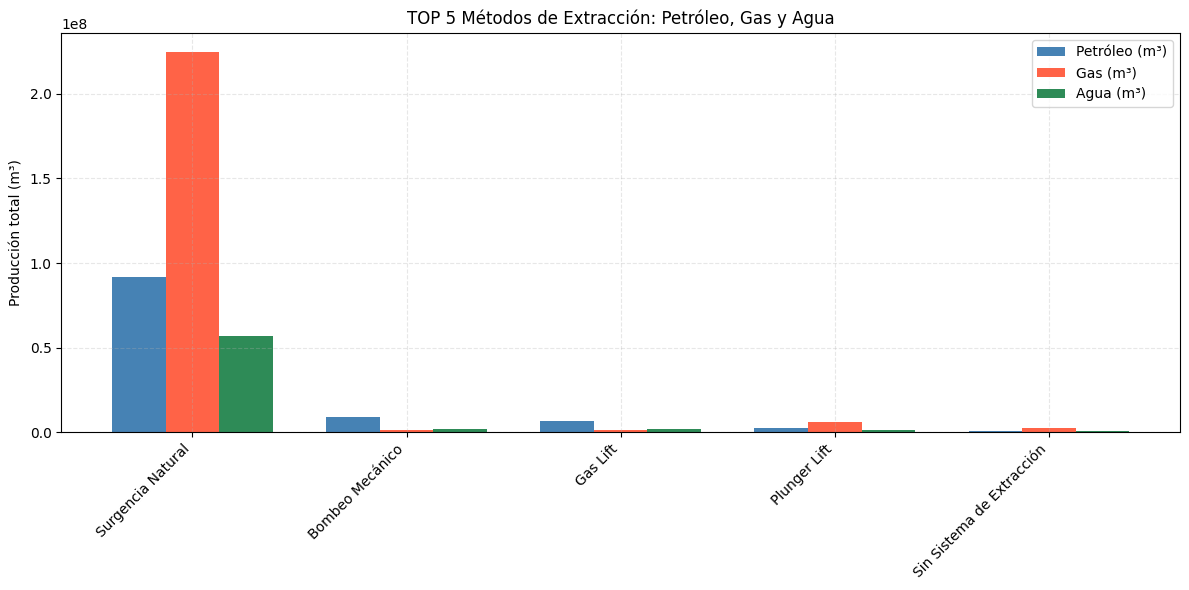

In [ ]:
# Agrupamos por tipo de extracción
prod_tipoext = df.groupby('tipoextraccion')[['prod_pet', 'prod_gas', 'prod_agua']].sum()

# Ordenamos por producción total (oil+gas+agua)
prod_tipoext['total'] = prod_tipoext.sum(axis=1)
prod_tipoext = prod_tipoext.sort_values('total', ascending=False)

# Quitamos la columna 'total' para graficar
prod_tipoext = prod_tipoext[['prod_pet', 'prod_gas', 'prod_agua']]

topN = 5

prod_tipoext_top = prod_tipoext.head(topN)

plt.figure(figsize=(12,6))
x = range(len(prod_tipoext_top))

plt.bar([i - 0.25 for i in x], prod_tipoext_top['prod_pet'], width=0.25, label='Petróleo (m³)', color='steelblue')
plt.bar(x,                          prod_tipoext_top['prod_gas'], width=0.25, label='Gas (m³)', color='tomato')
plt.bar([i + 0.25 for i in x],      prod_tipoext_top['prod_agua'], width=0.25, label='Agua (m³)', color='seagreen')

plt.xticks(x, prod_tipoext_top.index, rotation=45, ha='right')
plt.ylabel("Producción total (m³)")
plt.title(f"TOP {topN} Métodos de Extracción: Petróleo, Gas y Agua")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

###Producción de Petróleo, Gas y Agua por Formación

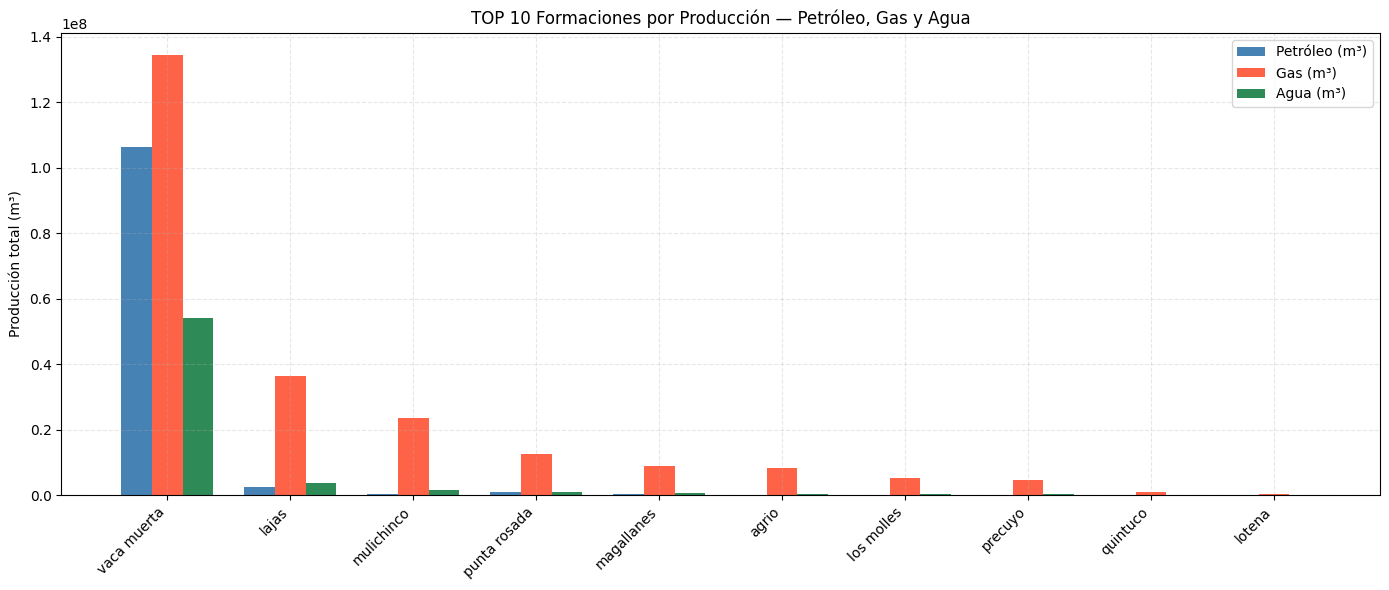

In [ ]:
# Agrupar por formación
prod_form = df.groupby('formacion')[['prod_pet', 'prod_gas', 'prod_agua']].sum()

# Ordenar por producción total (pet + gas + agua)
prod_form['total'] = prod_form.sum(axis=1)
prod_form = prod_form.sort_values('total', ascending=False)

# Quitar columna total para graficar
prod_form = prod_form[['prod_pet', 'prod_gas', 'prod_agua']]

# Tomar solo las top 10 formaciones (para que sea visible)
topN = 10
prod_form_top = prod_form.head(topN)

# Graficar
plt.figure(figsize=(14,6))
x = range(len(prod_form_top))

plt.bar([i - 0.25 for i in x], prod_form_top['prod_pet'], width=0.25, label='Petróleo (m³)', color='steelblue')
plt.bar(x,                          prod_form_top['prod_gas'], width=0.25, label='Gas (m³)', color='tomato')
plt.bar([i + 0.25 for i in x],      prod_form_top['prod_agua'], width=0.25, label='Agua (m³)', color='seagreen')

plt.xticks(x, prod_form_top.index, rotation=45, ha='right')
plt.ylabel("Producción total (m³)")
plt.title(f"TOP {topN} Formaciones por Producción — Petróleo, Gas y Agua")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


###Boxplot de Profundidad por Formación (TOP 15 formaciones con más pozos)

/tmp/ipython-input-2407779647.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


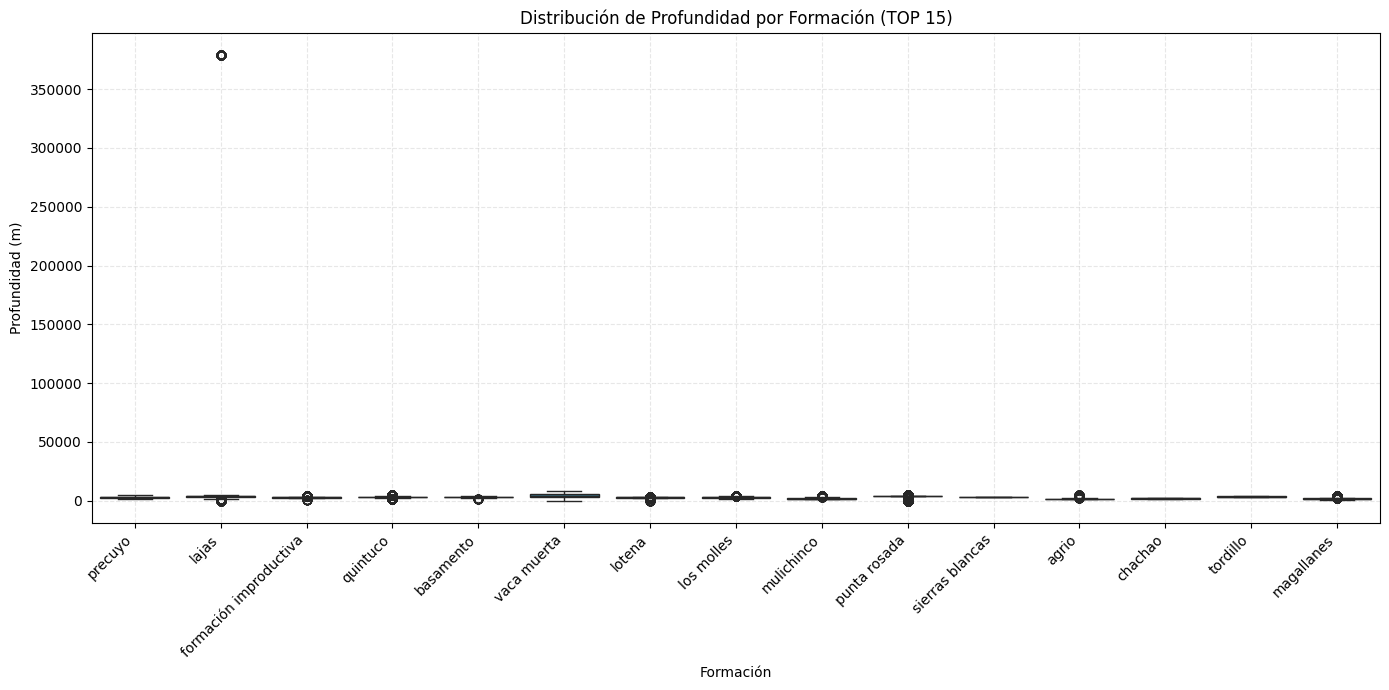

In [ ]:
# --- Seleccionar las formaciones más frecuentes ---
top_formaciones = df['formacion'].value_counts().head(15).index
df_top = df[df['formacion'].isin(top_formaciones)]

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_top,
    x='formacion',
    y='profundidad',
    palette='viridis'
)

plt.xticks(rotation=45, ha='right')
plt.xlabel("Formación")
plt.ylabel("Profundidad (m)")
plt.title("Distribución de Profundidad por Formación (TOP 15)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Se observa que hay valores de profundidad sumamente altos, por lo cual es imposible, entonces se procede a investigar esos datos.

In [ ]:
umbral_raro = 10000

pozos_raros = df[df['profundidad'] > umbral_raro][
    ['idpozo', 'formacion', 'profundidad', 'tipoextraccion']
]

pozos_raros



,idpozo,formacion,profundidad,tipoextraccion
333,156804,lajas,378939.0,Surgencia Natural
338,156804,lajas,378939.0,Surgencia Natural
830,156804,lajas,378939.0,Surgencia Natural
1019,156804,lajas,378939.0,Surgencia Natural
1565,156804,lajas,378939.0,Surgencia Natural
...,...,...,...,...
256658,156804,lajas,378939.0,Surgencia Natural
256767,156804,lajas,378939.0,Surgencia Natural
257048,156804,lajas,378939.0,Surgencia Natural
257201,156804,lajas,378939.0,Surgencia Natural


Se prodece a eliminar esos pozos con profundidad errónea o mal tipeada

In [ ]:
# Eliminar profundidades imposibles (> 10.000 m)
df = df[df['profundidad'] <= 10000].copy()

print("Dataset limpio listo para graficar.")
print("Cantidad de filas:", len(df))
print("Profundidad máxima:", df['profundidad'].max())


Dataset limpio listo para graficar.
Cantidad de filas: 372418
Profundidad máxima: 8264.0


Ahora se grafica nuevamente la distribución de profundidad en función de la formación

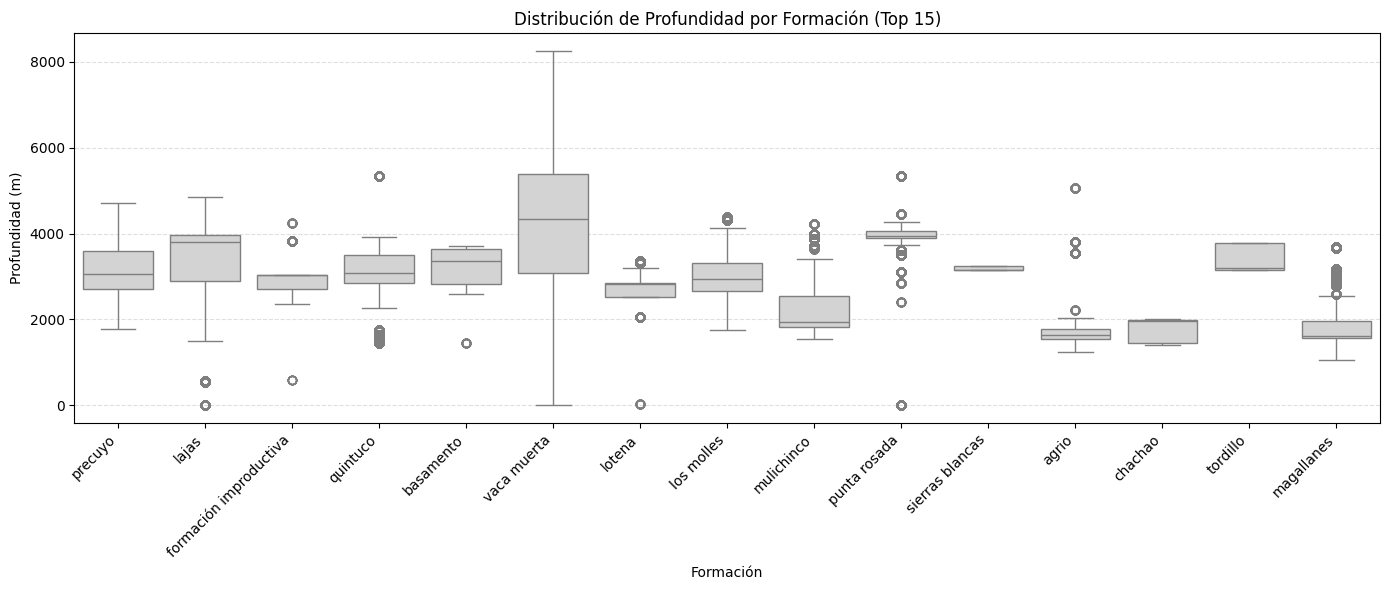

In [ ]:
# Seleccionar formaciones más frecuentes
formaciones_top = df['formacion'].value_counts().head(15).index

df_top = df[df['formacion'].isin(formaciones_top)]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top,
    x='formacion',
    y='profundidad',
    showfliers=True,   # mostramos outliers reales
    color='lightgray'
)

plt.xticks(rotation=45, ha='right')
plt.title("Distribución de Profundidad por Formación (Top 15)")
plt.xlabel("Formación")
plt.ylabel("Profundidad (m)")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


### Pozos vs Profundidad y Produccion total de oil

In [ ]:
df[df['profundidad'] == 0].shape[0]


4318

Se observa que existen 4318 filas con valor 0 en la columna "profundidad".

In [ ]:
pozos_con_profundidad_cero = df[df['profundidad'] == 0]['idpozo'].nunique()
pozos_con_profundidad_cero


128

Entonces, aproximadamente el 2,7% (128) de los pozos no tienen valor de profundidad.

Por lo tanto, vamos a solo considerar los valores no nulos de profunidad para nuestro df

In [ ]:
df = df[(df['profundidad'] > 0) & (df['profundidad'] < 10000)].copy()
df.shape


(368100, 26)

In [ ]:
df[df['profundidad'] < 1000][['idpozo', 'profundidad']].drop_duplicates().sort_values('profundidad')


,idpozo,profundidad
221135,158079,2.454
221124,162702,4.050
222146,165289,4.635
221581,163371,5.235
228296,166666,5.552
221196,162596,5.659
221190,162595,5.670
221334,162122,5.700
221289,162357,5.724
221286,162126,5.760


Se observan valores de profundidad menores a 10m por lo cual se deduce que es un error de tipeo con uso incorrecto de separador decimal. Por lo tanto solo a esos valores se los considera como valores en unidades de mil.

In [ ]:
df.loc[df['profundidad'] < 100, 'profundidad'] = df['profundidad'] * 1000


### Pairplot_Evaluación grafica de variables principales.
Con el objetivo de explorar gráficamente posibles relaciones entre variables numéricas, se realizará un pairplot sobre una muestra de aproximadamente 20 000 observaciones. La muestra fue obtenida mediante un muestreo estratificado proporcional por formación geológica, de modo de preservar el peso relativo de cada formación dentro de la población total y garantizar la representatividad del conjunto para el análisis exploratorio.

In [ ]:
n_total = 20000
df_sample = (
    df.groupby('formacion', group_keys=False)
      .apply(lambda x: x.sample(
          n=max(1, int(len(x) * n_total / len(df))),
          random_state=42
      ))
)



/tmp/ipython-input-1202644897.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [ ]:
df_sample.describe()

,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,tef,fechaingreso,profundidad,coordenadax,coordenaday,fecha_data
count,19988.000000,19988.000000,19988.000000,19988.000000,19988.000000,19988.000000,19988.000000,19988,19988.000000,19988.000000,19988.000000,19988
mean,2020.199119,6.470082,150208.972233,283.634111,600.900035,163.016421,21.968436,2020-11-17 06:17:50.589205760,3636.603945,-68.839968,-38.961595,2020-09-25 08:12:46.539923968
min,2006.000000,1.000000,3640.000000,0.000000,0.000000,0.000000,0.000000,2006-11-13 13:57:53.058895,301.000000,-71.998310,-69.415770,2006-01-31 00:00:00
25%,2018.000000,4.000000,145882.000000,0.000000,8.457500,0.000000,14.600000,2018-06-17 19:59:34.406614528,2870.000000,-69.181060,-38.763204,2018-05-31 00:00:00
50%,2021.000000,6.000000,155539.000000,6.455000,103.808700,11.195000,29.176695,2021-08-09 14:55:55.677133056,3235.000000,-68.869000,-38.508198,2021-07-31 00:00:00
75%,2023.000000,9.000000,159663.000000,94.162500,457.178850,75.162250,30.630000,2023-12-11 12:13:44.220734976,4475.000000,-68.494508,-38.319396,2023-11-30 00:00:00
max,2025.000000,12.000000,166750.000000,11766.761000,24756.770000,17468.160000,31.000000,2025-10-20 11:04:27.206611,7784.000000,-38.590070,-24.116560,2025-09-30 00:00:00
std,4.003310,3.389266,18503.380938,825.700588,1529.906893,549.884739,12.173358,NaN,1260.375538,0.638855,2.434580,NaN


In [ ]:
vars_pair = [
    'prod_pet',
    'prod_gas',
    'prod_agua',
    'profundidad',
    'anio'
]


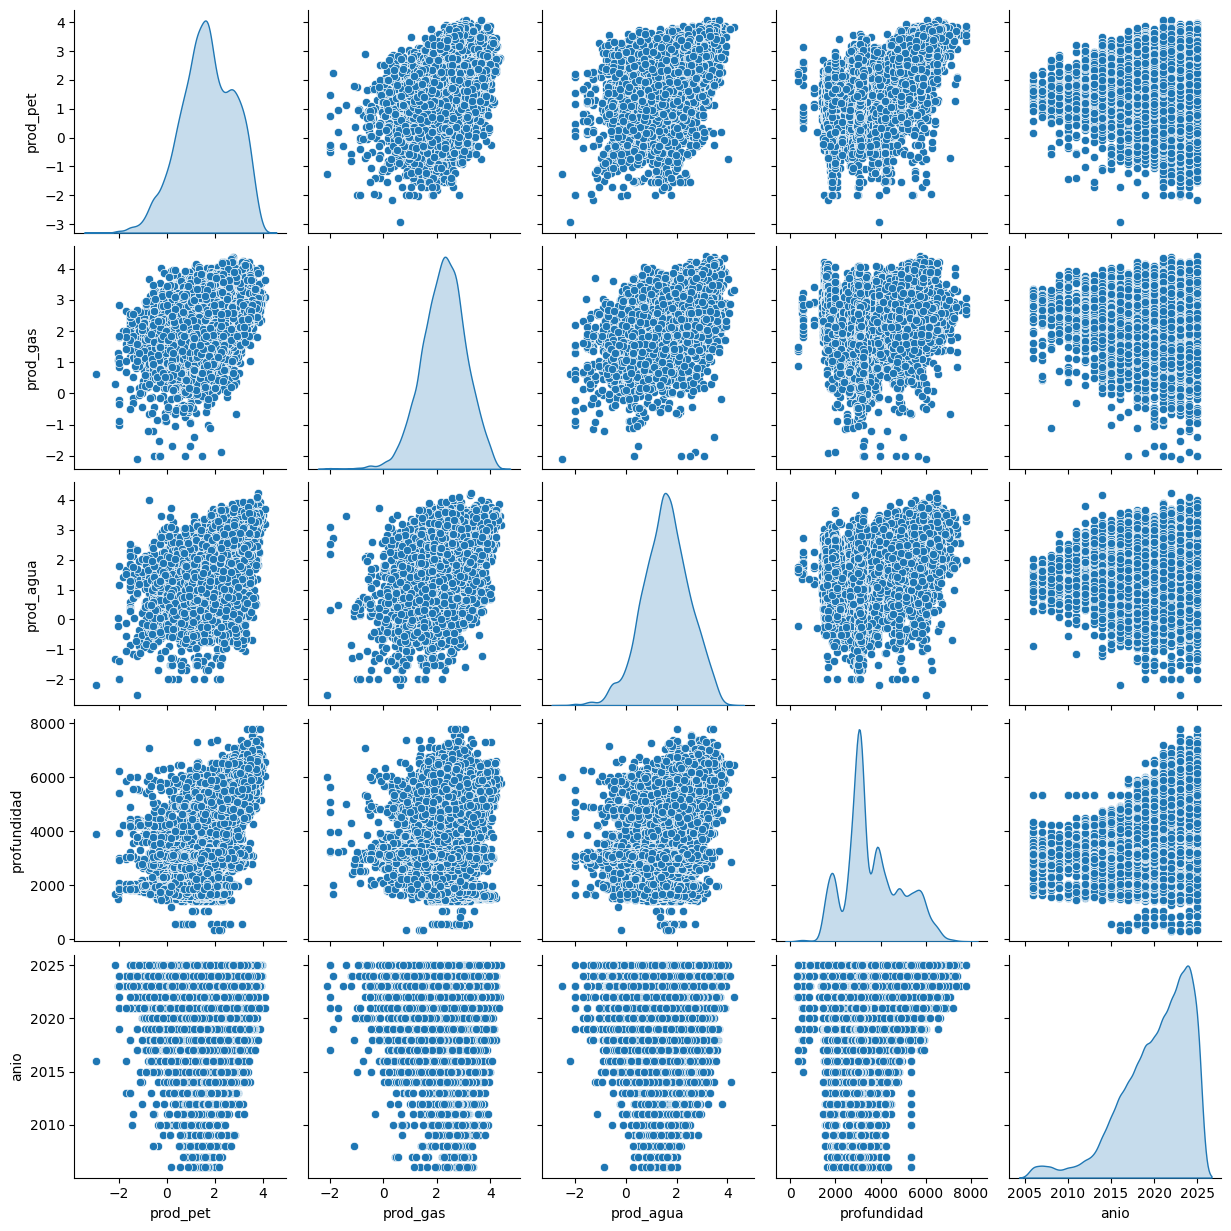

In [ ]:
df_pair = df_sample[vars_pair].copy()
for col in ['prod_pet', 'prod_gas', 'prod_agua']:
    df_pair[col] = df_pair[col].replace(0, np.nan)
    df_pair[col] = np.log10(df_pair[col])
sns.pairplot(df_pair, diag_kind='kde')
plt.show()

El pairplot construido a partir de una muestra estratificada del dataset permite observar visualmente las relaciones entre las principales variables numéricas. Se identifican asociaciones positivas moderadas entre las producciones de petróleo y agua, así como entre gas y agua, mientras que la relación entre petróleo y gas resulta débil. Asimismo, se observa una tendencia positiva entre la profundidad del pozo y la producción de petróleo, aunque con una elevada dispersión, lo que indica que la profundidad actúa como un factor influyente pero no determinante. No se evidencian tendencias temporales lineales claras entre las producciones y el año, mientras que sí se observa que los pozos perforados en años más recientes tienden a ser más profundos. En conjunto, el análisis visual confirma los resultados obtenidos mediante las matrices de correlación y pone de manifiesto la naturaleza heterogénea y no lineal del comportamiento productivo de los pozos.

###Evolución de los tipos de extracción a lo largo del tiempo

In [ ]:
pivot = df.groupby(['fecha_data', 'tipoextraccion']).size().unstack(fill_value=0)

# Cantidad total de pozos por tipo
conteo_tipos = pivot.sum().sort_values(ascending=False)

# Filtrar tipos "grandes" y "chicos"
tipos_principales = conteo_tipos[conteo_tipos > 600].index
tipos_secundarios = conteo_tipos[conteo_tipos <= 600].index

pivot_principales = pivot[tipos_principales]
pivot_secundarios = pivot[tipos_secundarios]

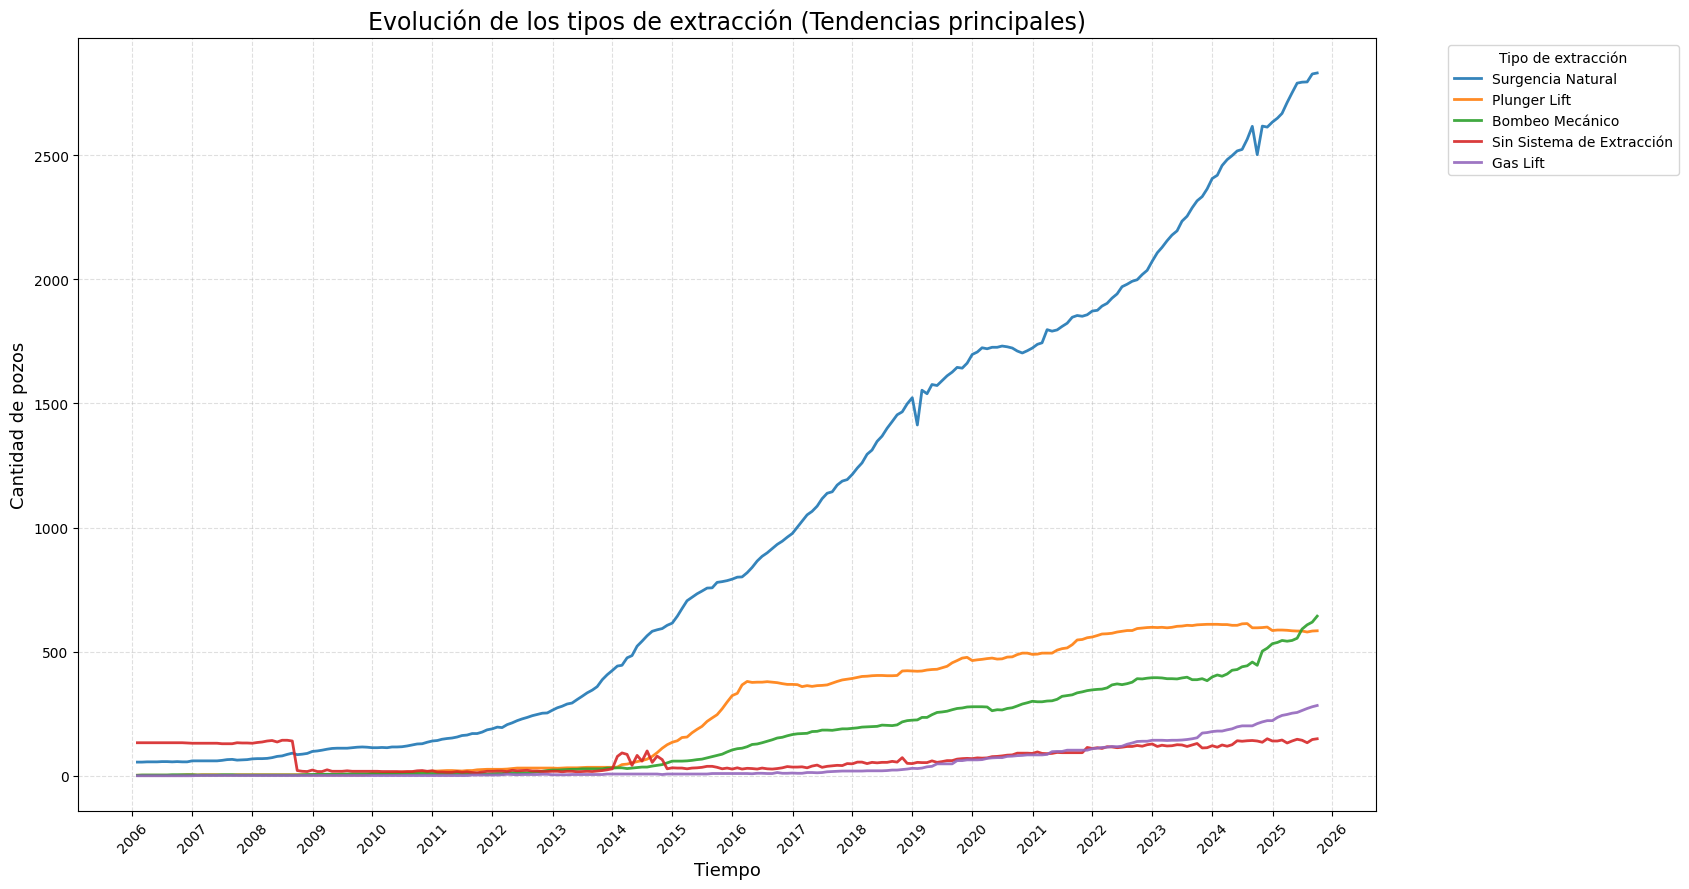

In [ ]:
import matplotlib.dates as mdates  # <-- Asegurate de tener esto en la celda de imports

plt.figure(figsize=(17,9))

for col, color in zip(pivot_principales.columns, ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']):
    plt.plot(pivot_principales.index, pivot_principales[col],
             label=col, linewidth=2, alpha=0.9, color=color)

plt.title("Evolución de los tipos de extracción (Tendencias principales)", fontsize=17)
plt.ylabel("Cantidad de pozos", fontsize=13)
plt.xlabel("Tiempo", fontsize=13)

# --- FORMATEAR FECHAS ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))       # cada 1 año
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # mostrar solo el año
plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Tipo de extracción", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


La Surgencia Natural es el sistema predominante durante todo el período, con un crecimiento muy marcado a partir de 2013–2014, coincidente con la expansión de desarrollos no convencionales.

El Plunger Lift muestra una adopción acelerada a partir de 2014, lo que sugiere su utilización como solución operativa en pozos con carga líquida.

El Bombeo Mecánico presenta un crecimiento progresivo y sostenido, consolidándose como uno de los métodos secundarios más utilizados.

El Gas Lift aparece en años más recientes y con menor cantidad de pozos, lo que indica una adopción más limitada dentro del dataset analizado.

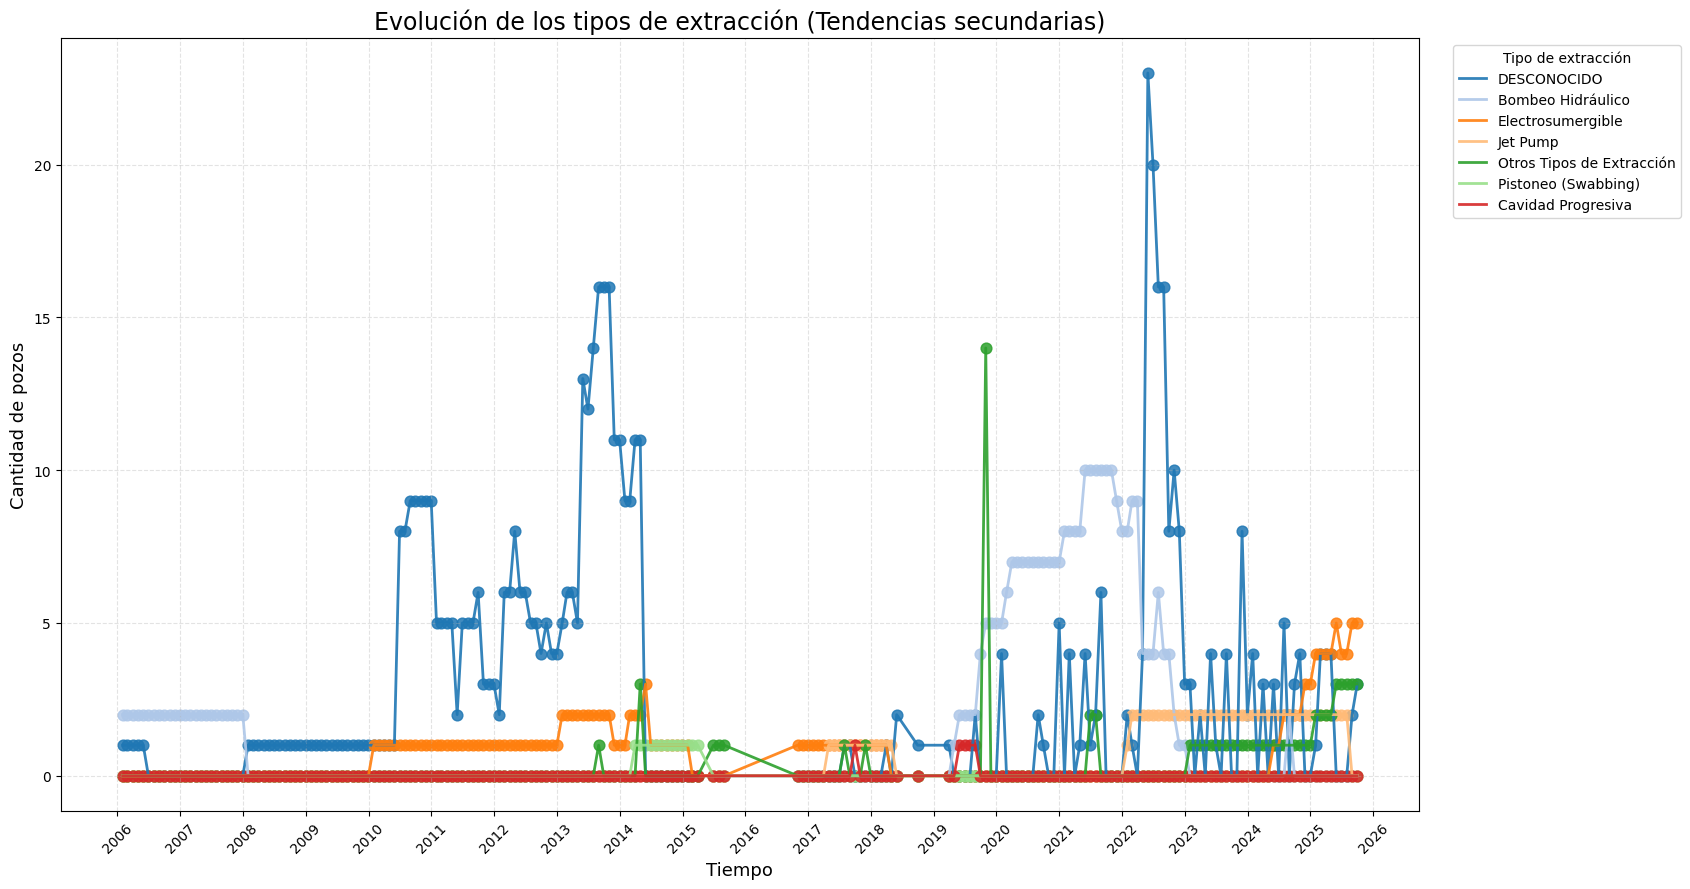

In [ ]:
# --------------------------------------------------
# 1) DEFINIR TIPOS PRINCIPALES (los excluidos)
# --------------------------------------------------
tipos_principales = [
    "Surgencia Natural",
    "Bombeo Mecánico",
    "Gas Lift",
    "Plunger Lift",
    "Sin Sistema de Extracción"
]

# --------------------------------------------------
# 2) ARMAR DATAFRAME DE SECUNDARIOS
# --------------------------------------------------
tipos_secundarios = [t for t in pivot.columns if t not in tipos_principales]

pivot_sec = pivot[tipos_secundarios].copy()
pivot_sec.index = pd.to_datetime(pivot_sec.index)

# Filtrar meses con cero total (ruido visual)
pivot_sec = pivot_sec[pivot_sec.sum(axis=1) > 0]

# Ordenar por importancia (solo estético)
pivot_sec = pivot_sec[pivot_sec.sum().sort_values(ascending=False).index]

# --------------------------------------------------
# 3) CREAR PALETA — colores únicos garantizados
# --------------------------------------------------
palette = sns.color_palette("tab20", n_colors=len(pivot_sec.columns))

# --------------------------------------------------
# 4) GRAFICAR
# --------------------------------------------------
plt.figure(figsize=(17,9))

for col, color in zip(pivot_sec.columns, palette):
    # línea
    plt.plot(
        pivot_sec.index,
        pivot_sec[col],
        color=color,
        linewidth=2,
        alpha=0.9,
        label=col
    )
    # puntos
    plt.scatter(
        pivot_sec.index,
        pivot_sec[col],
        color=color,
        s=60,
        alpha=0.85
    )

# --------------------------------------------------
# 5) AJUSTES VISUALES
# --------------------------------------------------
plt.title("Evolución de los tipos de extracción (Tendencias secundarias)", fontsize=17)
plt.ylabel("Cantidad de pozos", fontsize=13)
plt.xlabel("Tiempo", fontsize=13)

plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.35)

plt.legend(
    title="Tipo de extracción",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

El gráfico de tendencias secundarias muestra la evolución temporal de sistemas de extracción con baja participación dentro del dataset. Se observa que estos métodos presentan apariciones puntuales y cantidades reducidas de pozos, sin evidenciar una adopción sostenida en el tiempo. Este comportamiento indica que dichos sistemas tienen un rol marginal en el conjunto de datos analizado y no constituyen variables dominantes para el análisis productivo, motivo por el cual no se priorizan en las etapas posteriores de modelado.

##Conclusión del Análisis Exploratorio de Datos

El análisis exploratorio realizado permitió comprender en profundidad la estructura, distribución y relaciones principales del dataset de producción de pozos no convencionales. Las variables productivas (petróleo, gas y agua) presentan distribuciones altamente asimétricas, con fuerte concentración en valores bajos y presencia de pocos pozos que explican gran parte de la producción total, lo cual fue evidenciado mediante histogramas logarítmicos y gráficos de Pareto.

El análisis temporal y por tipo de extracción mostró una clara predominancia de la surgencia natural, junto con una adopción progresiva de sistemas artificiales como Plunger Lift y Bombeo Mecánico, mientras que los métodos secundarios tienen una participación marginal. A nivel geológico, la formación Vaca Muerta concentra la mayor parte de la producción, con diferencias significativas en profundidad entre formaciones.

Las matrices de correlación indican relaciones moderadas entre las variables productivas y la profundidad, mientras que las variables categóricas (en particular la formación y el sub-tipo de recurso) muestran asociaciones relevantes con las variables numéricas, justificando su inclusión en etapas posteriores de modelado. En conjunto, el dataset se encuentra correctamente depurado, estructurado y preparado para avanzar hacia el desarrollo de modelos predictivos de producción.

#Definición del problema y modelo

En el desarrollo de un nuevo pozo no convencional, una de las principales incertidumbres se presenta al momento de estimar su desempeño productivo inicial. Una vez finalizada la perforación y completación del pozo, se cuenta con información relevante como la formación objetivo, la profundidad alcanzada, el tipo de pozo, el diseño no convencional y el tipo de recurso (shale o tight). Sin embargo, el comportamiento productivo real solo se conoce luego de poner el pozo en producción.

En este contexto, el objetivo del presente trabajo es desarrollar un modelo capaz de estimar la producción mensual de un pozo, a partir de sus características geológicas y operativas conocidas previamente. La estimación se basa en el análisis de pozos históricos con características similares, utilizando la información disponible en el dataset para identificar patrones de comportamiento productivo.

Este tipo de predicción resulta de interés para la evaluación temprana del potencial productivo de nuevos pozos y puede servir como herramienta de apoyo en la planificación operativa y en la toma de decisiones.

## Selección de caracteristicas

De acuerdo con los resultados obtenidos en el Análisis Exploratorio de Datos (EDA), se definieron las variables de entrada y salida del modelo considerando tanto la disponibilidad de información previa a la puesta en producción del pozo como tambien lo observado en los análisis realizados.

###Variables de entrada
**Numericas**: prod_agua, prod_gas, mes y profundidad.

*Justificación*:

Las variables prod_gas y prod_agua mostraron correlaciones moderadas con prod_pet en la matriz de correlación numérica y patrones consistentes en los pairplots, indicando que aportan información relevante sobre el comportamiento productivo del pozo.

La variable profundidad presentó asociaciones claras con las producciones y diferencias marcadas entre formaciones, reflejando su importancia desde el punto de vista geológico y del diseño del pozo.

La varibale mes para tener idea en que momento de la vida del pozo estoy parado.

**Categoricas**: formacion, sub_tipo_recurso y tipoextraccion.

*Justificación*:

La variable formacion mostró una relación significativa con la profundidad y con los niveles de producción, concentrando gran parte del volumen producido y diferenciando comportamientos productivos entre pozos.

sub_tipo_recurso (Shale / Tight) evidenció asociaciones relevantes con la profundidad y la producción de petróleo, representando diferencias estructurales propias del tipo de reservorio.

tipoextraccion presentó patrones productivos diferenciados en los análisis exploratorios y representa una decisión operativa conocida al momento de iniciar la producción.

###Varibale Objetivo (target)
**Target**: prod_pet (producción mensual de petróleo del pozo)
*Justificación*:

El objetivo del proyecto es estimar la producción mensual de un pozo a partir de información conocida antes o al inicio de la puesta en producción (formación, tipo de recurso, profundidad, etc.). Se selecciona prod_pet por ser la variable más relevante para evaluar el desempeño productivo inicial y porque en el EDA se observaron patrones y asociaciones consistentes con las variables disponibles.

Nota: En esta etapa el modelo predicirá prod_pet como una variable continua (regresión).

##Modelo a utilizar

###Modelo seleccionado: Random Forest Regressor.

*Justificación:*

En el EDA no se observaron relaciones lineales fuertes o “limpias” para justificar una regresión lineal simple como modelo principal, por ejemplo, el grafico de Pairplot mostro cierta tendencia pero con un rango de valores muy disperso y posibles no linealidades.

Random Forest permite capturar relaciones no lineales e interacciones entre variables (por ejemplo, cómo cambia el efecto de profundidad dependiendo de formacion o sub_tipo_recurso), sin exigir supuestos fuertes de linealidad.

Es robusto frente a ruido y outliers y funciona bien como modelo base para obtener un desempeño sólido y luego comparar contra alternativas.

Nota: Las variables categóricas (formacion, sub_tipo_recurso, tipoextraccion) se transformarán mediante One-Hot Encoding (variables dummy).

“Con estas definiciones se procede a construir el dataset final de entrenamiento, aplicando el preprocesamiento correspondiente y separando conjuntos de entrenamiento y prueba para evaluar el desempeño del modelo.”

In [ ]:
import numpy as np
import pandas as pd

df_model = df[df["tipoestado"] == "Extracción Efectiva"].copy()

# IMPORTANTÍSIMO: ordenar por pozo y tiempo
df_model = df_model.sort_values(["idpozo", "anio", "mes"]).copy()

# 1) MEMORIA: lags de producción (lo que el pozo venía produciendo)
df_model["prod_pet_lag1"] = df_model.groupby("idpozo")["prod_pet"].shift(1)
df_model["prod_pet_lag2"] = df_model.groupby("idpozo")["prod_pet"].shift(2)

# Tendencia simple
df_model["delta_pet"] = df_model["prod_pet_lag1"] - df_model["prod_pet_lag2"]

# 2) "IDENTIDAD" DEL POZO SIN USAR idpozo como dummy:
# Promedio histórico hasta el mes anterior
df_model["mean_pet_to_date"] = (
    df_model.groupby("idpozo")["prod_pet"]
    .apply(lambda s: s.shift(1).expanding().mean())
    .reset_index(level=0, drop=True)
)

# Acumulado histórico hasta el mes anterior
df_model["cum_pet_to_date"] = (
    df_model.groupby("idpozo")["prod_pet"]
    .apply(lambda s: s.shift(1).cumsum())
    .reset_index(level=0, drop=True)
)

# Contador de meses en producción del pozo
df_model["meses_en_prod"] = df_model.groupby("idpozo").cumcount() + 1

# 3) Como ahora hay NaN en meses 1 y 2 por los lags, los sacamos del entrenamiento
df_model = df_model.dropna(subset=["prod_pet_lag1", "prod_pet_lag2", "mean_pet_to_date"]).copy()


In [ ]:
# 1) Definimos columnas
target = "prod_pet"

features_num = [
    "prod_agua", "prod_gas", "profundidad", "mes",
    "prod_pet_lag1", "prod_pet_lag2", "delta_pet",
    "mean_pet_to_date", "cum_pet_to_date", "meses_en_prod"
]

features_cat = ["formacion", "sub_tipo_recurso", "tipoextraccion"]
features = features_num + features_cat

X = df_model[features].copy()
y = df_model[target].copy()
groups = df_model["idpozo"].copy()


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
y_log = np.log1p(y)

train_idx, test_idx = next(gss.split(X, y_log, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_log.iloc[train_idx], y_log.iloc[test_idx]


print("Pozos train:", df_model.iloc[train_idx]["idpozo"].nunique())
print("Pozos test:", df_model.iloc[test_idx]["idpozo"].nunique())
print("Intersección (debería ser 0):",
      len(set(df_model.iloc[train_idx]["idpozo"]).intersection(set(df_model.iloc[test_idx]["idpozo"]))))


Pozos train: 3420
Pozos test: 856
Intersección (debería ser 0): 0


La partición de los datos se realizó utilizando GroupShuffleSplit, considerando el identificador de pozo como grupo, con el objetivo de evitar fuga de información entre los conjuntos de entrenamiento y prueba, garantizando que un mismo pozo no aparezca en ambos conjuntos.

In [ ]:
X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y_log.iloc[train_idx]  # Use y_log for training
y_test  = y_log.iloc[test_idx]   # Use y_log for testing


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# features_num = ["prod_agua", "prod_gas", "profundidad"]
# features_cat = ["formacion", "sub_tipo_recurso", "tipoextraccion"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
        ("num", "passthrough", features_num)
    ]
)

# Fit SOLO con train
X_train_enc = preprocessor.fit_transform(X_train)

# Transform en test (sin fit)
X_test_enc = preprocessor.transform(X_test)

print("X_train_enc shape:", X_train_enc.shape)
print("X_test_enc shape:", X_test_enc.shape)


X_train_enc shape: (233261, 47)
X_test_enc shape: (61984, 47)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [ ]:
rf = RandomForestRegressor(
    n_estimators=35,
    random_state=42,
    n_jobs=-1,
    max_depth=16,
    min_samples_split=20,
    min_samples_leaf=10
)


In [ ]:
rf.fit(X_train_enc, y_train)


RandomForestRegressor(max_depth=16, min_samples_leaf=10, min_samples_split=20,
                      n_estimators=35, n_jobs=-1, random_state=42)

In [ ]:
y_pred_log = rf.predict(X_test_enc)

# volver a escala real
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)
print("R2:", r2)


R2: 0.9435202569278811


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)


RMSE: 203.96289080176197


##Conclusión / Resumen de resultados

El modelo Random Forest obtuvo un R² alto (~0.94) y un RMSE relativamente bajo, lo que indica un  buen desempeño en la predicción de la producción mensual de petróleo.
Este resultado se explica principalmente porque el modelo incorpora memoria temporal del pozo (producción de meses anteriores, acumulados y tendencia), lo que le permite capturar el comportamiento típico de declinación y continuidad productiva de cada pozo.

La partición train/test se realizó por pozo (GroupShuffleSplit), evitando fuga de información.

Las variables históricas se calcularon solo con información pasada (shift), sin usar datos futuros.

El modelo generaliza razonablemente bien en pozos no vistos.

Sin embargo, se observa que los mayores errores ocurren en valores extremos de producción, donde el modelo tiende a suavizar picos muy altos o caídas abruptas, lo cual es esperable en modelos basados en promedios de comportamientos históricos.

En conjunto, el modelo resulta adecuado para estimaciones operativas mensuales, especialmente para analizar tendencias y comportamientos esperados, más que valores puntuales extremos.

###Comunicación de resultados

In [ ]:
df_compare = pd.DataFrame({
    "prod_real": y_true,   # real
    "prod_pred": y_pred    # real
})


In [ ]:
df_compare["mes"] = X_test["mes"].values
df_compare["idpozo"] = df_model.iloc[test_idx]["idpozo"].values

df_compare.head(20)


,prod_real,prod_pred,mes,idpozo,error,abs_error
280008,424.460,322.962112,12,42900,101.497888,101.497888
279177,399.063,316.847341,1,42900,82.215659,82.215659
279229,379.873,319.097459,2,42900,60.775541,60.775541
279278,198.361,320.873473,3,42900,-122.512473,122.512473
279355,233.624,197.697846,4,42900,35.926154,35.926154
279501,182.982,209.393028,5,42900,-26.411028,26.411028
279527,158.226,171.749154,6,42900,-13.523154,13.523154
279588,130.294,150.535671,7,42900,-20.241671,20.241671
279692,114.810,127.447369,8,42900,-12.637369,12.637369
279742,140.136,111.770974,9,42900,28.365026,28.365026


In [ ]:
df_tabla = X_test.copy()
df_tabla["idpozo"] = df_model.iloc[test_idx]["idpozo"].values
df_tabla["prod_real"] = y_true
df_tabla["prod_pred"] = y_pred
df_tabla["error"] = df_tabla["prod_real"] - df_tabla["prod_pred"]
df_tabla["abs_error"] = df_tabla["error"].abs()

df_tabla.head()


,prod_agua,prod_gas,profundidad,mes,prod_pet_lag1,prod_pet_lag2,delta_pet,mean_pet_to_date,cum_pet_to_date,meses_en_prod,formacion,sub_tipo_recurso,tipoextraccion,idpozo,prod_real,prod_pred,error,abs_error
280008,217.625,33.142,3120.0,12,476.373,409.519,66.854,442.946000,885.892,3,vaca muerta,SHALE,Bombeo Mecánico,42900,424.460,322.962112,101.497888,101.497888
279177,182.692,44.861,3120.0,1,424.460,476.373,-51.913,436.784000,1310.352,4,vaca muerta,SHALE,Bombeo Mecánico,42900,399.063,316.847341,82.215659,82.215659
279229,190.831,43.692,3120.0,2,399.063,424.460,-25.397,427.353750,1709.415,5,vaca muerta,SHALE,Bombeo Mecánico,42900,379.873,319.097459,60.775541,60.775541
279278,215.160,37.393,3120.0,3,379.873,399.063,-19.190,417.857600,2089.288,6,vaca muerta,SHALE,Bombeo Mecánico,42900,198.361,320.873473,-122.512473,122.512473
279355,147.235,45.060,3120.0,4,198.361,379.873,-181.512,381.274833,2287.649,7,vaca muerta,SHALE,Bombeo Mecánico,42900,233.624,197.697846,35.926154,35.926154


Los 5 peores errores fueron:

In [ ]:
cols_show = ["idpozo","mes","formacion","sub_tipo_recurso","tipoextraccion",
             "profundidad","prod_gas","prod_agua",
             "prod_pet_lag1","prod_pet_lag2","delta_pet",
             "mean_pet_to_date","cum_pet_to_date","meses_en_prod",
             "prod_real","prod_pred","error","abs_error"]

df_tabla.sort_values("abs_error", ascending=False)[cols_show].head()


,idpozo,mes,formacion,sub_tipo_recurso,tipoextraccion,profundidad,prod_gas,prod_agua,prod_pet_lag1,prod_pet_lag2,delta_pet,mean_pet_to_date,cum_pet_to_date,meses_en_prod,prod_real,prod_pred,error,abs_error
272596,166221,8,vaca muerta,SHALE,Surgencia Natural,5910.0,10743.1470,4068.132,1296.662,35.908,1260.754,666.2850,1332.570,3,10160.470,2665.297773,7495.172227,7495.172227
254601,163299,10,vaca muerta,SHALE,Surgencia Natural,6109.0,831.7100,1998.340,2766.020,1618.210,1147.810,2192.1150,4384.230,3,9635.190,4217.566387,5417.623613,5417.623613
280781,163628,7,vaca muerta,SHALE,Surgencia Natural,6244.0,2695.5300,1767.050,4181.290,4134.100,47.190,4621.7825,18487.130,5,8822.350,4203.998092,4618.351908,4618.351908
326204,166522,7,vaca muerta,SHALE,Surgencia Natural,5920.0,441.4848,3344.956,1840.997,0.000,1840.997,920.4985,1840.997,3,8834.231,4273.130935,4561.100065,4561.100065
277750,164858,12,vaca muerta,SHALE,Surgencia Natural,6555.0,9069.9110,6921.960,1876.668,121.257,1755.411,739.6444,3698.222,6,6761.541,2308.098964,4453.442036,4453.442036


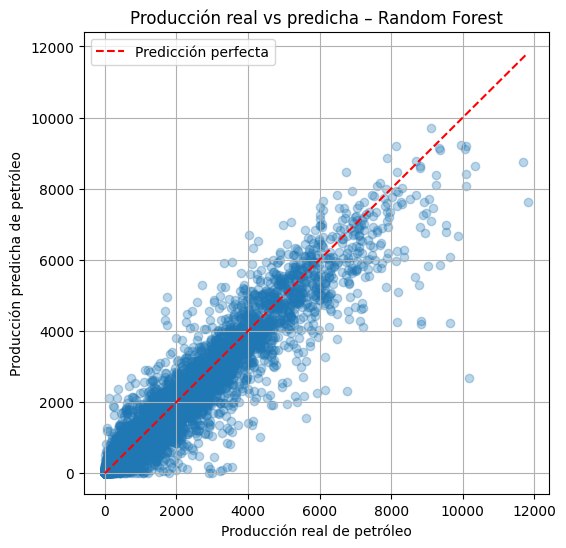

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# Scatter real vs predicho
plt.scatter(y_true, y_pred, alpha=0.3)

# Línea ideal y = x
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Producción real de petróleo")
plt.ylabel("Producción predicha de petróleo")
plt.title("Producción real vs predicha – Random Forest")
plt.legend()
plt.grid(True)

plt.show()


El modelo reproduce correctamente la tendencia general de la producción mensual, aunque presenta mayor dispersión en valores extremos.

In [ ]:
import numpy as np

# pozos que quedaron en test
pozos_test = df_model.iloc[test_idx]["idpozo"].unique()

# elegimos uno al azar (después podés cambiarlo a mano)
pozo_id = np.random.choice(pozos_test)
print("Pozo elegido:", pozo_id)


Pozo elegido: 157946


In [ ]:
df_pozo_real = df_model[
    (df_model["idpozo"] == pozo_id)
].sort_values("mes")

df_pozo_real[["mes", "prod_pet"]].head(20)


,mes,prod_pet
281137,1,0.000000
287555,1,0.000000
287466,1,3.277882
287949,1,1.853719
287793,1,3.666470
288126,1,0.369707
288209,1,1.152977
287496,1,1.199706
289217,2,1.978929
288758,2,3.359607


In [ ]:
# X real del pozo (solo features)
X_pozo = df_pozo_real[features].copy()

# aplicar el MISMO preprocesador entrenado
X_pozo_enc = preprocessor.transform(X_pozo)

# predicción (en log)
y_pozo_pred_log = rf.predict(X_pozo_enc)

# volver a escala real
y_pozo_pred = np.expm1(y_pozo_pred_log)


In [ ]:
df_curva = pd.DataFrame({
    "mes": df_pozo_real["mes"].values,
    "prod_real": df_pozo_real["prod_pet"].values,
    "prod_pred": y_pozo_pred
})

df_curva


,mes,prod_real,prod_pred
0,1,0.000000,0.017279
1,1,0.000000,0.010805
2,1,3.277882,1.865667
3,1,1.853719,2.184030
4,1,3.666470,3.186145
...,...,...,...
95,12,2.373804,2.270396
96,12,3.618255,4.953667
97,12,0.480592,0.906435
98,12,7.497025,3.439191


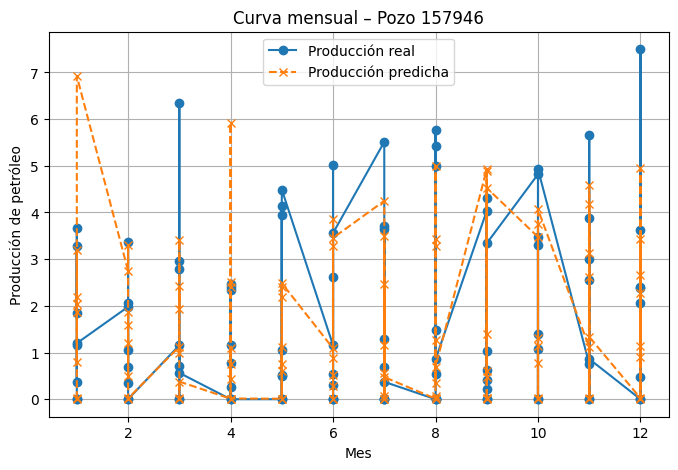

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df_curva["mes"],
    df_curva["prod_real"],
    marker="o",
    label="Producción real"
)

plt.plot(
    df_curva["mes"],
    df_curva["prod_pred"],
    marker="x",
    linestyle="--",
    label="Producción predicha"
)

plt.xlabel("Mes")
plt.ylabel("Producción de petróleo")
plt.title(f"Curva mensual – Pozo {pozo_id}")
plt.legend()
plt.grid(True)
plt.show()


El modelo logra reproducir la dinámica temporal de producción de los pozos, capturando tendencias y cambios mes a mes. Las diferencias observadas se explican por eventos operativos no modelados (paradas, abandonos, reparaciones, etc).

##Propuestas de implementación

Como fue dicho anteriormente, este modelo desarrollado permite estimar la producción mensual de petróleo por pozo, teniendo como datos información geológica, operativa y el comportamiento histórico del pozos patrones.

A partir de estos resultados, se identifican las siguientes aplicaciones prácticas:

###Pronóstico de producción mensual para planificación operativa y detección temprana de anomalías productivas.

Al inicio de cada mes, el modelo puede generar una producción esperada por pozo.

Este valor puede compararse con: Producción real medida, objetivos operativos

Impacto operativo: Me permite anticipar desvíos productivos, priorizar pozos con desempeño inferior al esperado y ajsutar planes de mantenimiento u operativos.

“Este pozo debería estar produciendo X m³ según históricos similares; si produce mucho menos, se investiga.”

Definir umbrales de alerta (ej. ±20–30 %).

Esto puede inferir en ciertas causas como:

Posibles problemas mecánicos

Daños de formación

Ingreso de agua inesperado

Eficiencia reducida del sistema de extracción


###Evaluación de desempeño por tipo de pozo y formación

Agrupar resultados del modelo por:

Formación

Tipo de recurso (shale / tight)

Sistema de extracción

Esto permite comparar qué combinaciones presentan mejor desempeño esperado y retroalimentar decisiones de desarrollo futuro.

Por ejemplo: “Para esta formación, el modelo muestra que los pozos con surgencia natural mantienen mejor producción mensual esperada.”

###Insumo para tableros de control (Power BI / dashboards)

Implementación real seria: Integrar el output del modelo en un dashboard.En donde me permita visualizar la produccion real, produccion esperada, desvío por pozo, tendencia mensual, etc.


##Posibles mejoras del modelo

Seria muy valioso incorporar variables adicionales como:

Presión de fondo

Intervenciones operativas

Datos de workover

Tiempos de uso por tipo de sistema de extracción

 ## Conclusión

En este trabajo se desarrolló un modelo de Machine Learning basado en Random Forest para predecir la producción mensual de petróleo por pozo, utilizando información operativa, geológica y el comportamiento histórico de cada pozo. Para evitar fuga de información, los datos se separaron mediante un esquema de validación por pozo (GroupShuffleSplit), garantizando una evaluación realista del desempeño del modelo.

Los resultados obtenidos muestran un buen nivel de ajuste, reflejado en métricas como R² y RMSE, lo que indica que el modelo es capaz de capturar relaciones no lineales complejas y patrones productivos relevantes. La incorporación de variables de memoria temporal (lags y promedios históricos) permitió mejorar la capacidad predictiva, representando de manera más realista la evolución de la producción en el tiempo.

Si bien el modelo no reemplaza el conocimiento de campo ni los análisis de ingeniería tradicionales, constituye una herramienta complementaria objetiva y reproducible, útil para anticipar comportamientos productivos, detectar desvíos y apoyar la toma de decisiones operativas. Entre sus principales limitaciones se encuentra la dependencia de la calidad de los datos disponibles y la ausencia de variables dinámicas como presión o eventos operativos específicos, lo cual abre oportunidades de mejora futura.

En conjunto, el enfoque propuesto demuestra el potencial del Machine Learning como apoyo a la gestión de producción en la industria Oil & Gas, aportando valor tanto en el análisis histórico como en la planificación operativa.